### **A Data-Driven Framework for Predicting Bond Strength and Failure Modes in NSM CFRP Strips**
### Five-Model Ensemble Machine Learning Pipeline with SHAP-Based Interpretability

| Field | Detail |
|---|---|
| **Regression Target** | **`Bond Strength`**|
| **Classification Target** | **`Failure Modes`  (C  ,  R  ,  DAC  ,  DFA)** |
| **Dataset** | **130 NSM FRP specimens collected from experimental studies and published literature using 15 input features** |
| **Models** | **ExtraTrees  ,  RandomForest  ,  GradientBoosting  ,**  **XGBoost**  ,  **LightGBM** |

### Pipeline Architecture

| Step | Module |
|------|--------|
| 1 | Data Loading & Preprocessing|
| 2 | Feature Abbreviation Mapping|
| 3 | Exploratory Data Analysis |
| 4 | 80/20 Train-Test Split with Stratified Classification Sampling |
| 5 | Hyperparameter Tuning|
| 6 | Individual Model Evaluation on the test set |
| 7 | **Dynamic Top-3 Model Selection Based on Validation Performance** (R2 for regression  -  Macro-F1 for classification) |
| 8 | Final Ensemble Prediction Using Voting Regressor and Soft Voting Classifier |
| 9 | High-quality visualisations saved to `outputs/` |
| 10 | **SHAP**-Based Global and Local Feature Interpretability Analysis |
| 11 | **Final Model Predictions and Export** |

---
> *Feature abbreviations follow standard notation commonly used in NSM FRP bond mechanics literature.*

In [ ]:
import subprocess, sys
pkgs = ["scikit-learn", "xgboost", "lightgbm", "shap", "openpyxl", "xlsxwriter"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("All packages ready.")

All packages ready.


---
## Section 1 – Library Import and Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import shap

warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.ensemble import (
    RandomForestRegressor,  ExtraTreesRegressor,  GradientBoostingRegressor,
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    VotingRegressor, VotingClassifier,
)
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    cross_val_score, KFold, StratifiedKFold,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA as SKPCA
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, confusion_matrix, classification_report, f1_score,
)
from scipy.stats import randint, uniform
from xgboost  import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

np.random.seed(42)

sns.set_style("white")
plt.rcParams.update({
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "white",
    "axes.grid"          : False,
    "axes.edgecolor"     : "#888888",
    "axes.linewidth"     : 0.8,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,

    "font.family"        : "Liberation Serif",
    "font.size"          : 16,
    "font.weight"        : "bold",

    "axes.labelsize"     : 16,
    "axes.titlesize"     : 16,
    "axes.titleweight"   : "bold",
    "axes.labelweight"   : "bold",

    "xtick.labelsize"    : 14,
    "ytick.labelsize"    : 14,
    "xtick.major.size"   : 4,
    "ytick.major.size"   : 4,

    "legend.frameon"     : False,
    "legend.fontsize"    : 13,

    "figure.dpi"         : 180,
    "savefig.bbox"       : "tight",
})

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

print("Libraries loaded | Liberation Serif 16 pt bold active.")

Libraries loaded | Liberation Serif 16 pt bold active.


---
## Section 2  -  Global Configuration

All tunable constants are defined here for easy modification before re-running the pipeline.

In [ ]:
DATA_FILE  = "NSM_FRP_Strength_Failure_Dataset.xlsx"
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
print(f"Output directory: {OUTPUT_DIR}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

INPUT_COLS = [
    "Concrete Compressive Strength",
    "Epoxy Shear Strength",
    "FRP tensile strength",
    "FRP thickness",
    "FRP width",
    "Groove thickness",
    "Groove width",
    "FRP perimeter of the failure plane",
    "Perimeter length of groove",
    "Aspect ratio of FRP cross-section",
    "FRP cross-sectional area",
    "Bonded Area of FRP strip",
    "Bonded area of the groove",
    "Bonded Length",
    "Edge distance",
]
TARGET_REG   = "Ultimate Load"
TARGET_CLS   = "Failure"
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_ITER       = 25    # RandomizedSearchCV iterations per model
CV_FOLDS     = 5     # inner CV folds

print(f"Input features : {len(INPUT_COLS)}")
print(f"Output dir     : {OUTPUT_DIR}/")
print(f"Random state   : {RANDOM_STATE}")
print(f"CV folds       : {CV_FOLDS}")

Output directory: /content/outputs
Input features : 15
Output dir     : /content/outputs/
Random state   : 42
CV folds       : 5


---
## Section 3  -  Feature Abbreviation Mapping

Short-form labels based on standard NSM FRP bond mechanics notation are used only for visualisation purposes.;
the models train on the raw numerical arrays.

> *If you have a reference image with custom short forms, update the `ABBREV` dict below.*

In [ ]:
ABBREV = {
    "Concrete Compressive Strength"       : r'$f_c$',
    "Epoxy Shear Strength"                : r'$\tau_e$',
    "FRP tensile strength"                : r'$f_f$',
    "FRP thickness"                       : r'$t_p$',
    "FRP width"                           : r'$b_p$',
    "Groove thickness"                    : r'$t_g$',
    "Groove width"                        : r'$b_g$',
    "FRP perimeter of the failure plane"  : r'$L_{\mathrm{per}(p)}$',
    "Perimeter length of groove"          : r'$L_{\mathrm{per}(g)}$',
    "Aspect ratio of FRP cross-section"   : r'$\beta$',
    "FRP cross-sectional area"            : r'$A_p$',
    "Bonded Area of FRP strip"            : r'$A_{b(p)}$',
    "Bonded area of the groove"           : r'$A_{b(g)}$',
    "Bonded Length"                       : r'$L_b$',
    "Edge distance"                       : r'$a_e$',
}

ABBREV_LABELS = [ABBREV[c] for c in INPUT_COLS]

print(f"{'Label':>24}   Full Name")
print("-" * 64)
for full, label in ABBREV.items():
    print(f"{label:>24}   {full}")

                   Label   Full Name
----------------------------------------------------------------
                   $f_c$   Concrete Compressive Strength
                $\tau_e$   Epoxy Shear Strength
                   $f_f$   FRP tensile strength
                   $t_p$   FRP thickness
                   $b_p$   FRP width
                   $t_g$   Groove thickness
                   $b_g$   Groove width
   $L_{\mathrm{per}(p)}$   FRP perimeter of the failure plane
   $L_{\mathrm{per}(g)}$   Perimeter length of groove
                 $\beta$   Aspect ratio of FRP cross-section
                   $A_p$   FRP cross-sectional area
              $A_{b(p)}$   Bonded Area of FRP strip
              $A_{b(g)}$   Bonded area of the groove
                   $L_b$   Bonded Length
                   $a_e$   Edge distance


---
## Section 4  -  Data Loading & Preprocessing

- Load the Excel file.
- Construct feature matrix `X`, regression target `y_load`, and encoded classification target `y_fail`.

In [ ]:
df = pd.read_excel(DATA_FILE)
print(f"Dataset shape : {df.shape}")

if "Specimen Name" in df.columns:
    df.drop(columns=["Specimen Name"], inplace=True)

missing = [c for c in INPUT_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

X      = df[INPUT_COLS].values.astype(float)
y_load = df[TARGET_REG].values.astype(float)

le      = LabelEncoder()
y_fail  = le.fit_transform(df[TARGET_CLS])
CLASSES = le.classes_

print(f"\nFeature matrix shape : {X.shape}")
print(
    f"Ultimate Load statistics (kN) | "
    f"min={y_load.min():.2f}, "
    f"max={y_load.max():.2f}, "
    f"mean={y_load.mean():.2f}, "
    f"std={y_load.std():.2f}"
)
print(f"Number of input features : {X.shape[1]}")
print(f"Number of specimens      : {X.shape[0]}")
print(f"Failure classes : {CLASSES.tolist()}")
print(f"\nClass distribution:")
print(df[TARGET_CLS].value_counts().rename_axis("Class")
      .reset_index(name="Count").to_string(index=False))

Dataset shape : (130, 18)

Feature matrix shape : (130, 15)
Ultimate Load statistics (kN) | min=20.34, max=205.10, mean=66.47, std=40.22
Number of input features : 15
Number of specimens      : 130
Failure classes : ['C', 'DAC', 'DFA', 'R']

Class distribution:
Class  Count
  DAC     62
    R     28
  DFA     28
    C     12


---
## Section 5  -  Exploratory Data Analysis

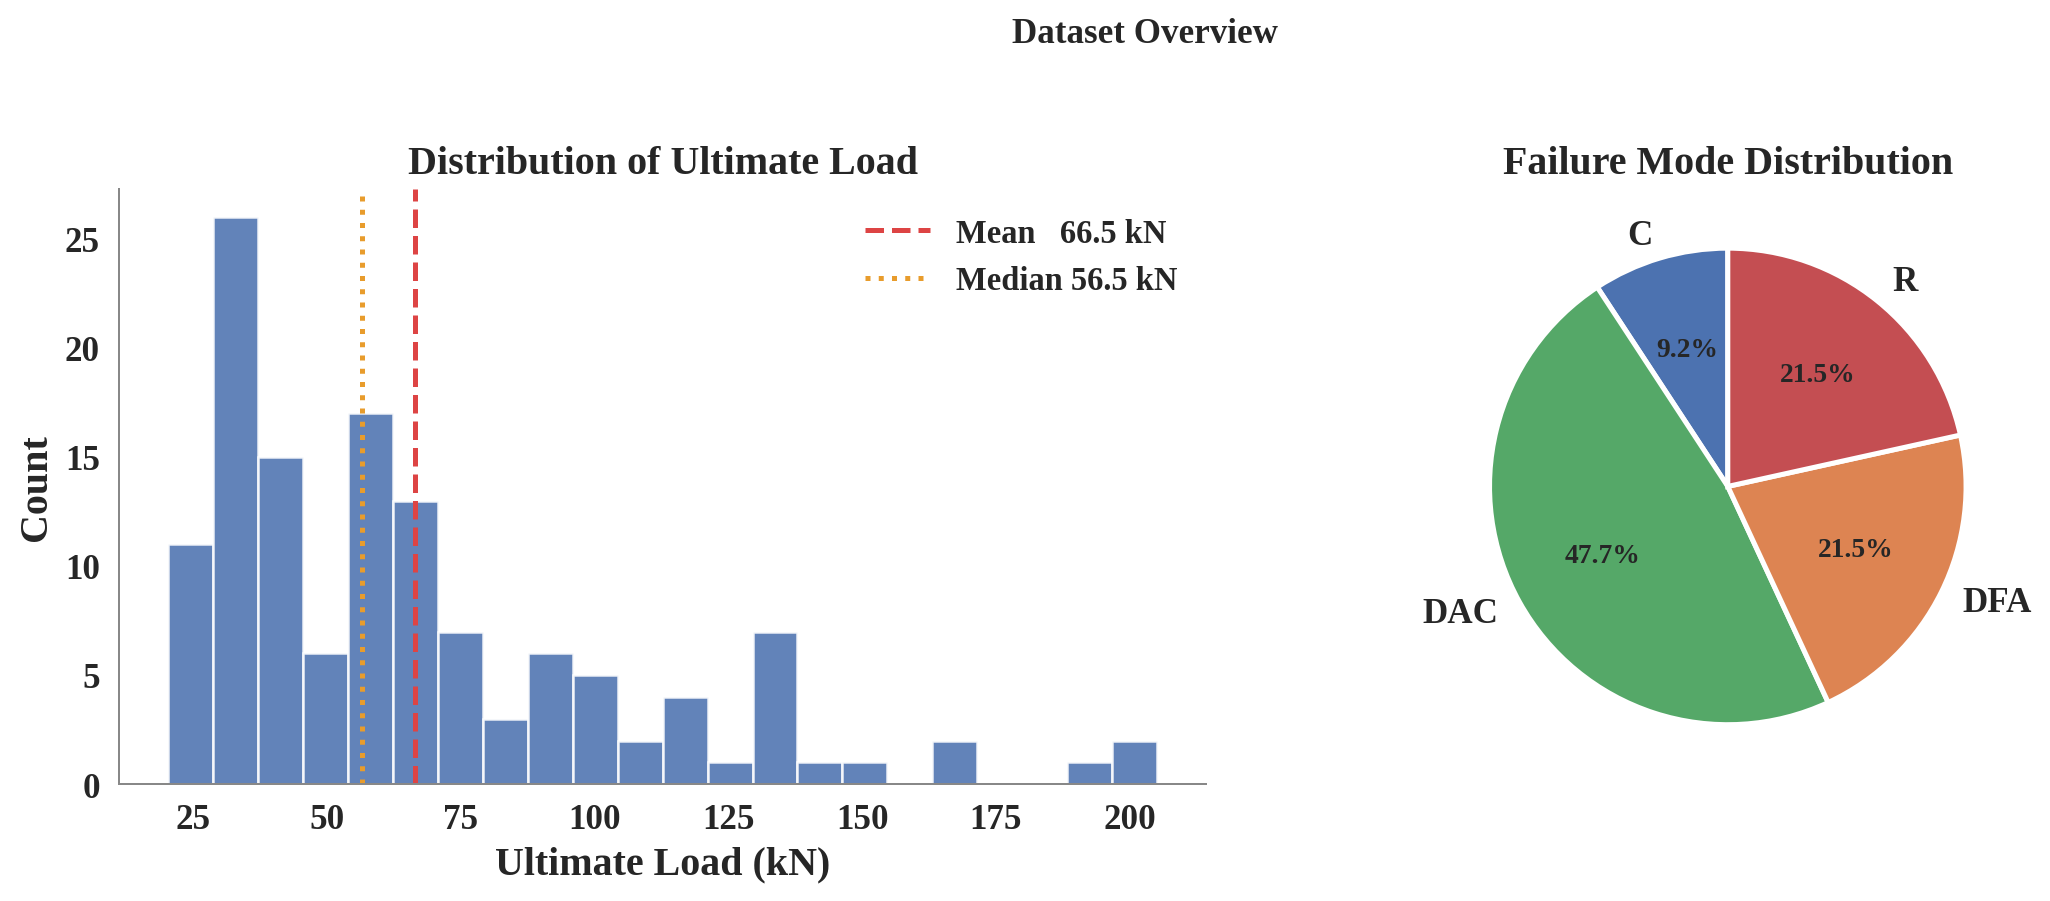

Saved -> /content/outputs/00a_distributions.png


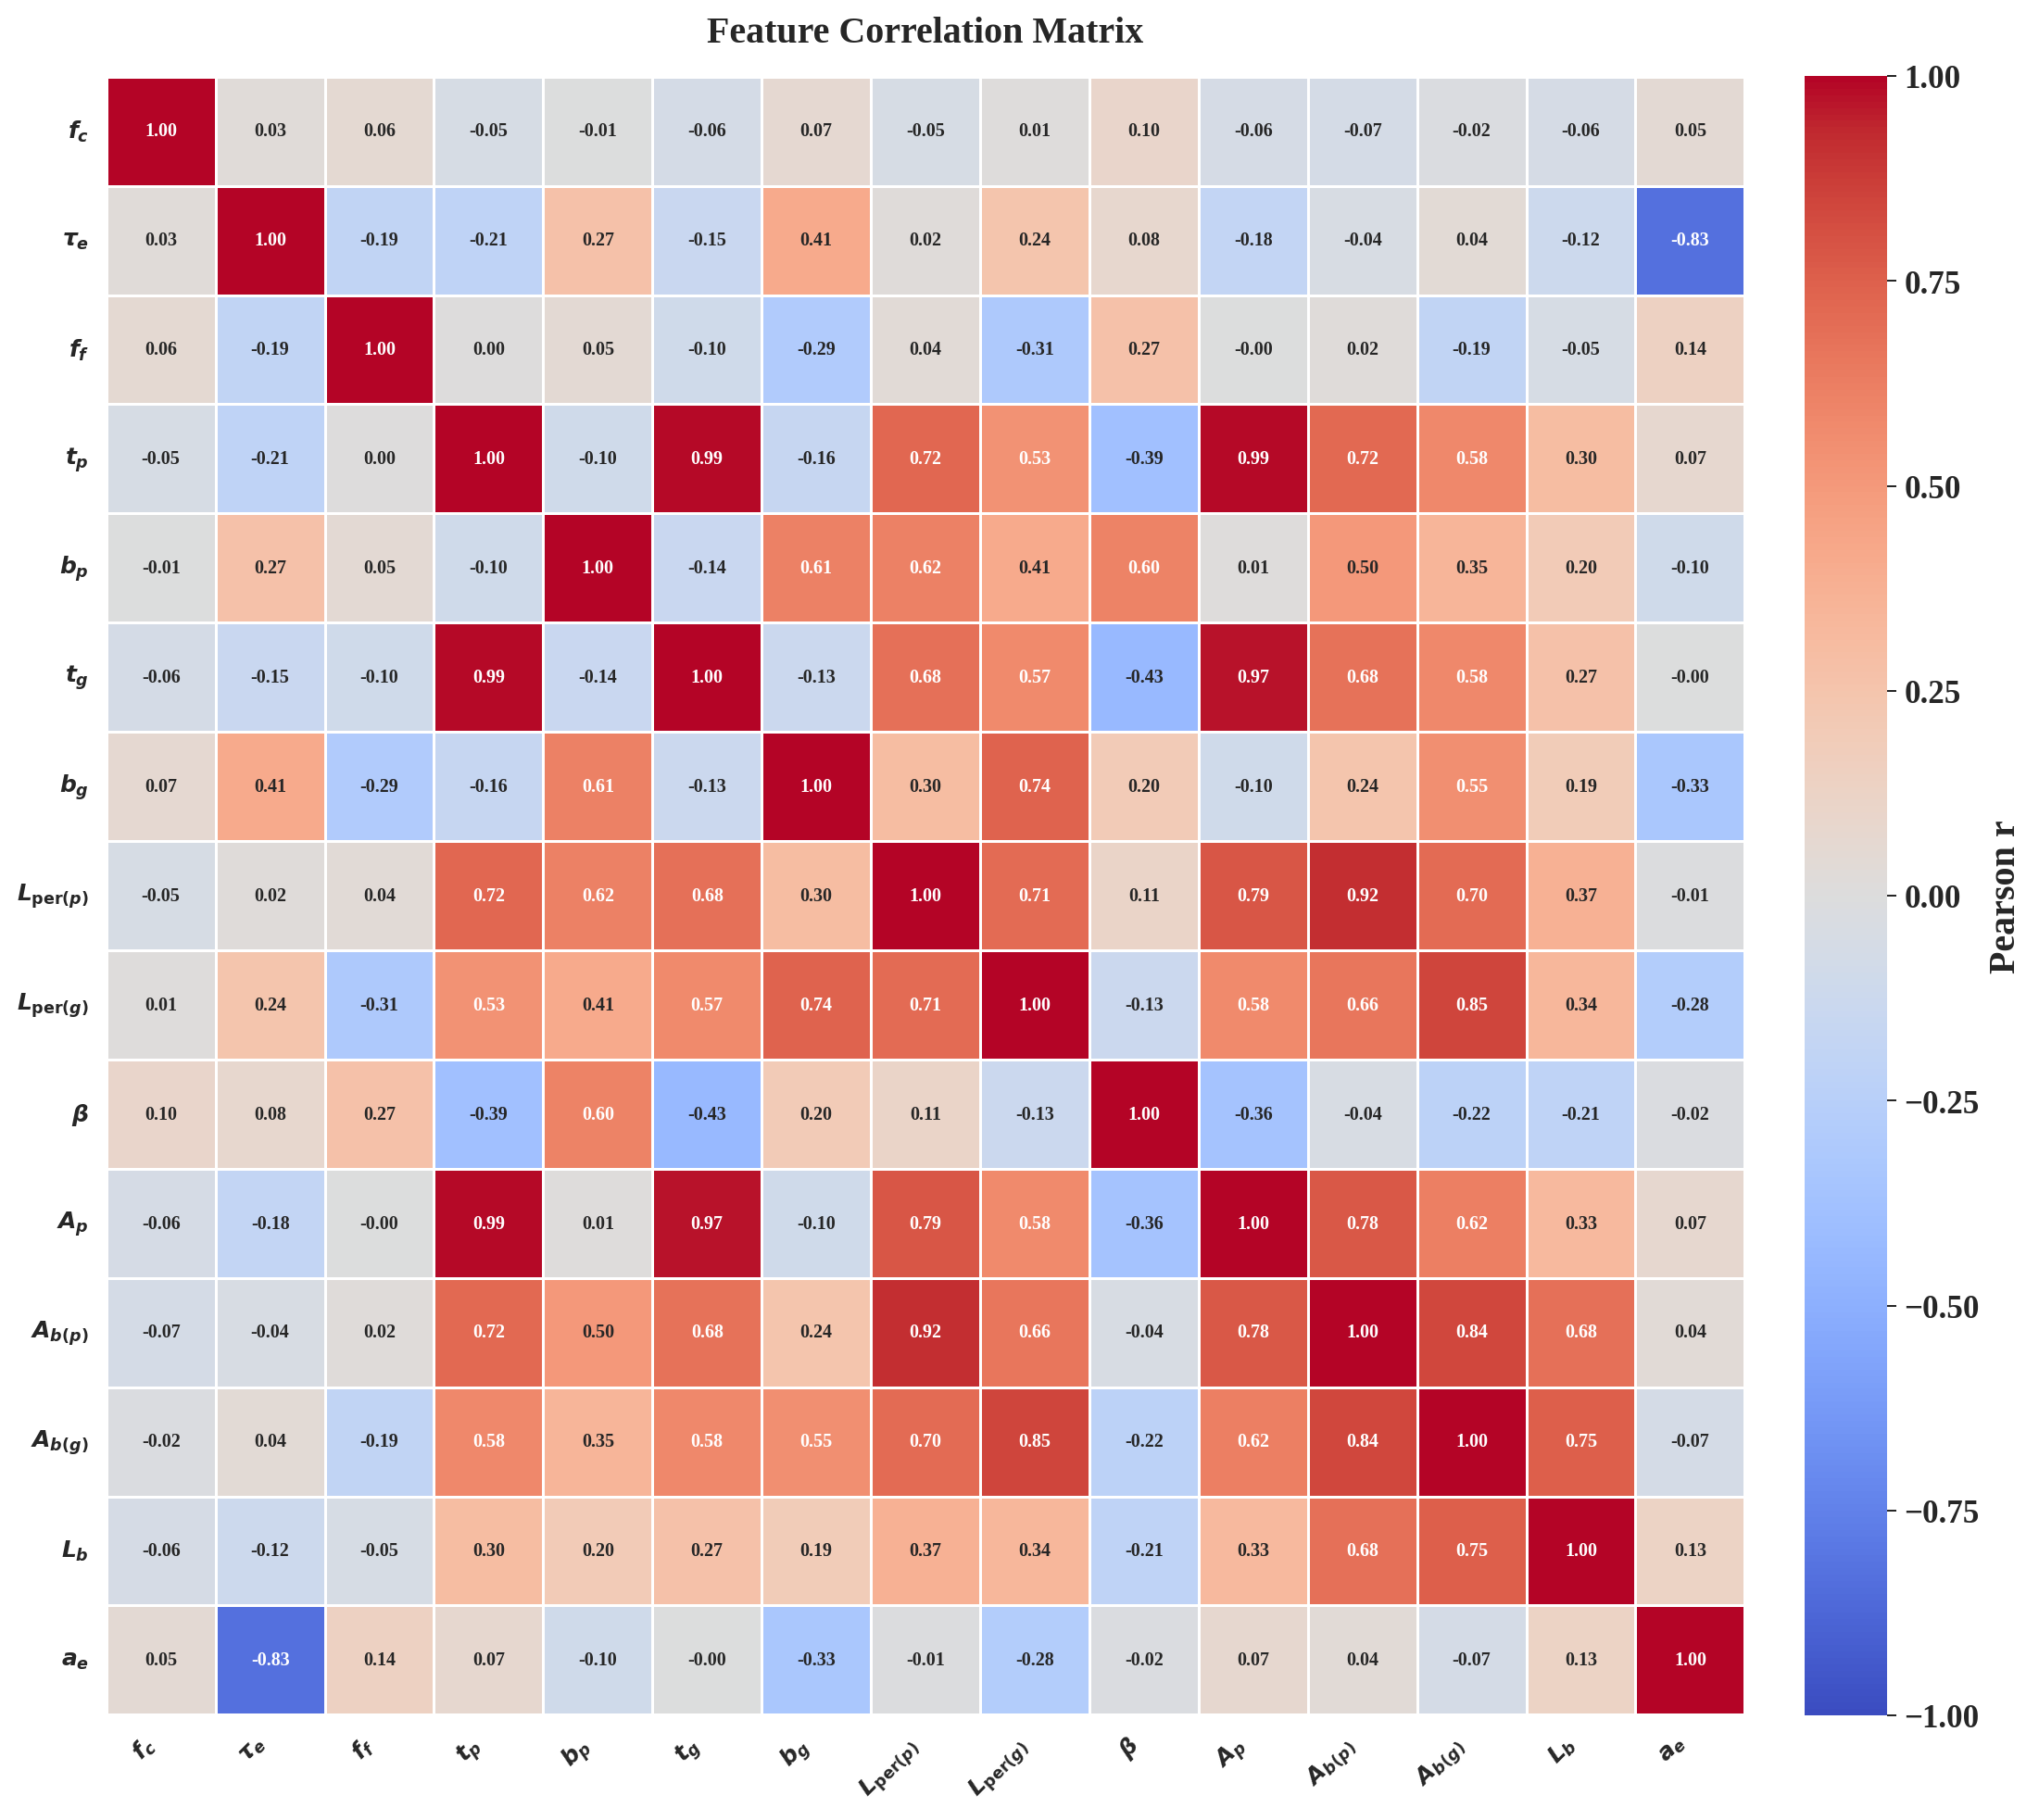

Saved -> /content/outputs/00b_correlation.png


In [ ]:
# -- 1. Distribution overview -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ultimate load distribution
ax = axes[0]
ax.hist(y_load, bins=22, color="#4C72B0", edgecolor="white", alpha=0.88, lw=0.6)

ax.axvline(
    y_load.mean(),
    color="#DD4444",
    lw=2,
    ls="--",
    label=f"Mean   {y_load.mean():.1f} kN"
)

ax.axvline(
    np.median(y_load),
    color="#E89C2C",
    lw=2,
    ls=":",
    label=f"Median {np.median(y_load):.1f} kN"
)

ax.set_xlabel("Ultimate Load (kN)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Ultimate Load")
ax.legend()
despine(ax)

# Failure mode distribution
ax = axes[1]
vc = df[TARGET_CLS].value_counts().reindex(CLASSES, fill_value=0)

pal = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

wedges, texts, autotexts = ax.pie(
    vc.values,
    labels=vc.index,
    autopct="%1.1f%%",
    colors=pal[:len(vc)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")

ax.set_title("Failure Mode Distribution")

plt.suptitle("Dataset Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

out = f"{OUTPUT_DIR}/00a_distributions.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")


# -- 2. Full annotated correlation matrix --------------------
X_df = pd.DataFrame(X, columns=ABBREV_LABELS)
corr_matrix = X_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Pearson r",
        "shrink": 1,
        "aspect": 20,
        "pad": 0.03
    },
    annot_kws={"size": 8},
    ax=ax
)

ax.set_xticklabels(ABBREV_LABELS, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ABBREV_LABELS, rotation=0, fontsize=10)

ax.set_title("Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()

out = f"{OUTPUT_DIR}/00b_correlation.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")

---
## Section 5b - Principal Component Analysis (PCA)

PCA reduces the 15-feature space to 2 principal components for visual inspection
of natural clustering by Failure Mode.
`StandardScaler` is applied first so no single feature dominates by scale.

PC1: 39.6%   PC2: 20.3%   Total: 60.0%


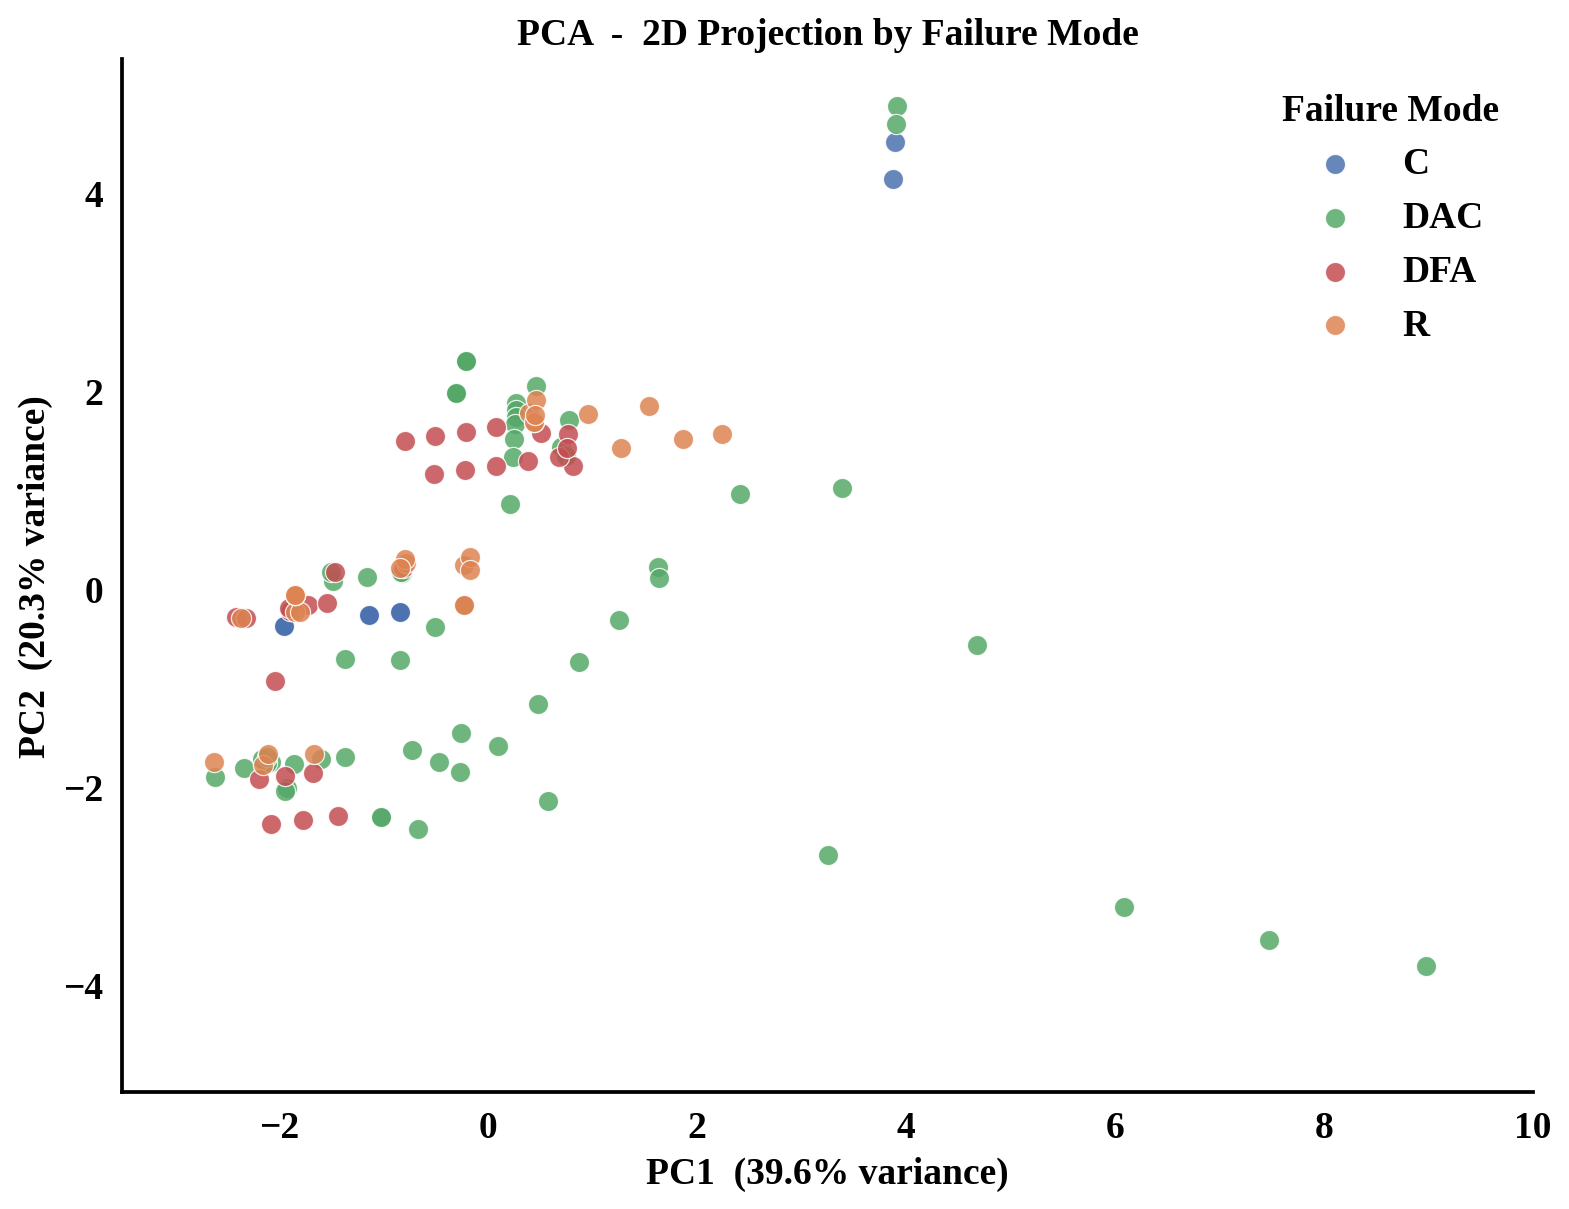

Saved -> /content/outputs/00c_pca.png


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SKPCA

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

pca    = SKPCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca.fit_transform(X_sc)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f"PC1: {var1:.1f}%   PC2: {var2:.1f}%   Total: {var1+var2:.1f}%")

CLASS_COLORS = {
    "C": "#4C72B0",
    "R": "#DD8452",
    "DAC": "#55A868",
    "DFA": "#C44E52"
}

labels_full = df[TARGET_CLS].values

fig, ax = plt.subplots(figsize=(9, 7))

for cls in CLASSES:
    mask = (labels_full == cls)
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=cls,
        color=CLASS_COLORS.get(cls, "#888888"),
        s=65,
        alpha=0.85,
        edgecolors="white",
        lw=0.5
    )

# Axis labels and title
ax.set_xlabel(
    f"PC1  ({var1:.1f}% variance)",
    fontsize=15,
    fontweight="bold",
    color="black"
)

ax.set_ylabel(
    f"PC2  ({var2:.1f}% variance)",
    fontsize=15,
    fontweight="bold",
    color="black"
)

ax.set_title(
    "PCA  -  2D Projection by Failure Mode",
    fontsize=15,
    fontweight="bold",
    color="black"
)

ax.set_xlim(-3.5, 10)

ax.tick_params(
    axis="both",
    labelsize=15,
    width=1.5,
    colors="black"
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")

leg = ax.legend(
    title="Failure Mode",
    fontsize=15,
    title_fontsize=15,
    frameon=False
)

leg.get_title().set_fontweight("bold")
leg.get_title().set_color("black")

for text in leg.get_texts():
    text.set_fontweight("bold")
    text.set_color("black")

despine(ax)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")

plt.tight_layout()

out = f"{OUTPUT_DIR}/00c_pca.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")

---
## Section 6  -  Stratified Train / Test Split

An 80/20 stratified train-test split was applied based on the failure mode labels to preserve class proportions in both subsets.

In [ ]:
(
    X_train, X_test,
    y_load_train, y_load_test,
    y_fail_train, y_fail_test
) = train_test_split(
    X,
    y_load,
    y_fail,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_fail
)

print(f"Train : {X_train.shape[0]} samples ({100 * X_train.shape[0] / len(X):.1f}%)")
print(f"Test  : {X_test.shape[0]} samples ({100 * X_test.shape[0] / len(X):.1f}%)")
print(f"Random state used : {RANDOM_STATE}")

print("\nClass distribution after split:")
print(f"{'Class':<8} {'Train':>7} {'Test':>7}")
print("-" * 24)

for enc, lbl in enumerate(CLASSES):
    n_tr = int((y_fail_train == enc).sum())
    n_te = int((y_fail_test == enc).sum())
    print(f"{lbl:<8} {n_tr:>7} {n_te:>7}")

Train : 104 samples (80.0%)
Test  : 26 samples (20.0%)
Random state used : 42

Class distribution after split:
Class      Train    Test
------------------------
C             10       2
DAC           50      12
DFA           22       6
R             22       6


---
## Section 7  -  Hyperparameter Tuning

***RandomizedSearchCV*** was applied to each model using N_ITER iterations and CV_FOLDS-fold cross-validation. The scoring metrics were R² for regression and Macro-F1 for classification.

| # | Model | Library |
|---|-------|---------|
| 1 | Extra Trees | `sklearn` |
| 2 | Random Forest | `sklearn` |
| 3 | Gradient Boosting | `sklearn` |
| 4 | XGBoost | `xgboost` |
| 5 | LightGBM | `lightgbm` |

In [ ]:
PARAM_SPACES = {
    "ExtraTrees": {
        "n_estimators"     : randint(200, 800),
        "max_depth"        : [None, 5, 10, 15, 20, 30],
        "min_samples_leaf" : randint(1, 5),
        "min_samples_split": randint(2, 8),
        "max_features"     : ["sqrt", "log2", None],
    },
    "RandomForest": {
        "n_estimators"     : randint(200, 800),
        "max_depth"        : [None, 5, 10, 15, 20, 30],
        "min_samples_leaf" : randint(1, 5),
        "min_samples_split": randint(2, 8),
        "max_features"     : ["sqrt", "log2"],
    },
    "GradientBoosting": {
        "n_estimators"    : randint(100, 500),
        "learning_rate"   : uniform(0.01, 0.29),
        "max_depth"       : randint(2, 8),
        "subsample"       : uniform(0.5, 0.5),
        "min_samples_leaf": randint(1, 5),
    },
    "XGBoost": {
        "n_estimators"    : randint(100, 600),
        "learning_rate"   : uniform(0.01, 0.29),
        "max_depth"       : randint(2, 10),
        "subsample"       : uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5),
        "reg_alpha"       : uniform(0, 2.0),
        "reg_lambda"      : uniform(0, 2.0),
        "min_child_weight": randint(1, 6),
    },
    "LightGBM": {
        "n_estimators"    : randint(100, 600),
        "learning_rate"   : uniform(0.01, 0.29),
        "max_depth"       : randint(3, 12),
        "num_leaves"      : randint(15, 127),
        "subsample"       : uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5),
        "reg_alpha"       : uniform(0, 2.0),
        "reg_lambda"      : uniform(0, 2.0),
    },
}
print("Search spaces defined for:", list(PARAM_SPACES.keys()))

Search spaces defined for: ['ExtraTrees', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


In [ ]:
print("="*72)
print("   HYPERPARAMETER TUNING   -   REGRESSION  (Ultimate Load)")
print("="*72)

BASE_REG = {
    "ExtraTrees"      : ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "RandomForest"    : RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost"         : XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                                      eval_metric="rmse", verbosity=0),
    "LightGBM"        : LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}

tuned_reg = {}
cv_reg_r2 = {}

for name, model in BASE_REG.items():
    print(f"\n  [{name}]  {N_ITER} configs x {CV_FOLDS}-fold CV ...")
    rs = RandomizedSearchCV(
        model, PARAM_SPACES[name],
        n_iter=N_ITER, scoring="r2", cv=CV_FOLDS,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0, refit=True,
    )
    rs.fit(X_train, y_load_train)
    tuned_reg[name] = rs.best_estimator_
    cv_reg_r2[name] = rs.best_score_
    print(f"     Best CV R2 = {rs.best_score_:.4f}")

print("\nRegression tuning complete.")

   HYPERPARAMETER TUNING   -   REGRESSION  (Ultimate Load)

  [ExtraTrees]  25 configs x 5-fold CV ...
     Best CV R2 = 0.8711

  [RandomForest]  25 configs x 5-fold CV ...
     Best CV R2 = 0.8439

  [GradientBoosting]  25 configs x 5-fold CV ...
     Best CV R2 = 0.8707

  [XGBoost]  25 configs x 5-fold CV ...
     Best CV R2 = 0.8764

  [LightGBM]  25 configs x 5-fold CV ...
     Best CV R2 = 0.8723

Regression tuning complete.


In [ ]:
print("="*72)
print("   HYPERPARAMETER TUNING   -   CLASSIFICATION  (Failure Mode)")
print("="*72)

BASE_CLS = {
    "ExtraTrees"      : ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                              class_weight="balanced"),
    "RandomForest"    : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                               class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost"         : XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                       eval_metric="mlogloss", verbosity=0),
    "LightGBM"        : LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                        verbosity=-1, class_weight="balanced"),
}

tuned_cls = {}
cv_cls_f1 = {}

for name, model in BASE_CLS.items():
    print(f"\n  [{name}]  {N_ITER} configs x {CV_FOLDS}-fold CV ...")
    rs = RandomizedSearchCV(
        model, PARAM_SPACES[name],
        n_iter=N_ITER, scoring="f1_macro", cv=CV_FOLDS,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0, refit=True,
    )
    rs.fit(X_train, y_fail_train)
    tuned_cls[name] = rs.best_estimator_
    cv_cls_f1[name] = rs.best_score_
    print(f"     Best CV Macro-F1 = {rs.best_score_:.4f}")

print("\nClassification tuning complete.")

   HYPERPARAMETER TUNING   -   CLASSIFICATION  (Failure Mode)

  [ExtraTrees]  25 configs x 5-fold CV ...
     Best CV Macro-F1 = 0.7514

  [RandomForest]  25 configs x 5-fold CV ...
     Best CV Macro-F1 = 0.7518

  [GradientBoosting]  25 configs x 5-fold CV ...
     Best CV Macro-F1 = 0.7441

  [XGBoost]  25 configs x 5-fold CV ...
     Best CV Macro-F1 = 0.7653

  [LightGBM]  25 configs x 5-fold CV ...
     Best CV Macro-F1 = 0.7540

Classification tuning complete.


---
## Section 8  -  Individual Model Evaluation

Each tuned model was evaluated independently on the unseen test set using regression and classification performance metrics.

In [ ]:
reg_results = {}
cls_results = {}

for name, model in tuned_reg.items():
    p_te = model.predict(X_test)
    p_tr = model.predict(X_train)
    reg_results[name] = {
        "R2"      : r2_score(y_load_test,  p_te),
        "MAE"     : mean_absolute_error(y_load_test,  p_te),
        "RMSE"    : np.sqrt(mean_squared_error(y_load_test,  p_te)),
        "MAPE"    : np.mean(np.abs((y_load_test  - p_te)  / y_load_test))  * 100,
        "R2_tr"   : r2_score(y_load_train, p_tr),
        "MAE_tr"  : mean_absolute_error(y_load_train, p_tr),
        "RMSE_tr" : np.sqrt(mean_squared_error(y_load_train, p_tr)),
        "MAPE_tr" : np.mean(np.abs((y_load_train - p_tr) / y_load_train)) * 100,
        "preds"   : p_te,
    }

for name, model in tuned_cls.items():
    p_te = model.predict(X_test)
    p_tr = model.predict(X_train)
    cls_results[name] = {
        "Acc"    : accuracy_score(y_fail_test,  p_te),
        "F1"     : f1_score(y_fail_test,  p_te,  average="macro"),
        "Acc_tr" : accuracy_score(y_fail_train, p_tr),
        "F1_tr"  : f1_score(y_fail_train, p_tr, average="macro"),
        "preds"  : p_te,
    }

print(f"Regression models evaluated     : {len(tuned_reg)}")
print(f"Classification models evaluated : {len(tuned_cls)}")
print("Performance metrics stored successfully.")

Regression models evaluated     : 5
Classification models evaluated : 5
Performance metrics stored successfully.


---
## Section 9  -  Dynamic Top-3 Ensemble Selection

Models were ranked according to cross-validation performance on the training set.

The top-3 regression models were selected using mean R², while the top-3 classification models were selected using mean Macro-F1 score.

The selected models were combined using VotingRegressor and soft VotingClassifier ensembles.

In [ ]:
kf_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kf_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_cv_scores = {}
cls_cv_scores = {}

for name in tuned_reg:

    cv = cross_val_score(
        tuned_reg[name],
        X_train,
        y_load_train,
        cv=kf_reg,
        scoring="r2"
    )

    folds = " | ".join([f"Fold {j+1}: {v:.4f}" for j, v in enumerate(cv)])
    print(f"   5-Fold CV R2: {folds}")

    reg_cv_scores[name] = cv.mean()

for name in tuned_cls:

    cv = cross_val_score(
        tuned_cls[name],
        X_train,
        y_fail_train,
        cv=kf_cls,
        scoring="f1_macro"
    )

    folds = " | ".join([f"Fold {j+1}: {v:.4f}" for j, v in enumerate(cv)])
    print(f"   5-Fold CV Macro-F1: {folds}")

    cls_cv_scores[name] = cv.mean()

reg_ranking = sorted(reg_cv_scores.items(), key=lambda x: x[1], reverse=True)
cls_ranking = sorted(cls_cv_scores.items(), key=lambda x: x[1], reverse=True)

top3_reg = [n for n, _ in reg_ranking[:3]]
top3_cls = [n for n, _ in cls_ranking[:3]]

SEP = "=" * 68

print(SEP)
print("  TOP-3  REGRESSION  (Ultimate Load)")
print(SEP)
for rank, name in enumerate(top3_reg, 1):
    s = reg_results[name]
    print(f"\n  Rank {rank}: {name}")
    print(f"    Train  |  R2: {s['R2_tr']:.4f}  MAE: {s['MAE_tr']:.2f} kN  "
          f"RMSE: {s['RMSE_tr']:.2f} kN  MAPE: {s['MAPE_tr']:.2f}%")
    print(f"    Test   |  R2: {s['R2']:.4f}  MAE: {s['MAE']:.2f} kN  "
          f"RMSE: {s['RMSE']:.2f} kN  MAPE: {s['MAPE']:.2f}%")
    print(f"   Selection CV R2: {reg_cv_scores[name]:.4f}")
    cv = cross_val_score(tuned_reg[name], X_train, y_load_train,
                         cv=kf_reg, scoring="r2")
    folds = "  ".join(f"Fold {j+1}: {v:.4f}" for j, v in enumerate(cv))
    print(f"    5-Fold CV R2:  {folds}")
    print(f"    Mean: {cv.mean():.4f}  Std: {cv.std():.4f}")

print()
print(SEP)
print("  TOP-3  CLASSIFICATION  (Failure Mode)")
print(SEP)
for rank, name in enumerate(top3_cls, 1):
    s = cls_results[name]
    print(f"\n  Rank {rank}: {name}")
    print(f"    Train  |  Accuracy: {s['Acc_tr']*100:.2f}%  Macro-F1: {s['F1_tr']:.4f}")
    print(f"    Test   |  Accuracy: {s['Acc']*100:.2f}%  Macro-F1: {s['F1']:.4f}")
    print(f"   Selection CV Macro-F1: {cls_cv_scores[name]:.4f}")
    cv = cross_val_score(tuned_cls[name], X_train, y_fail_train,
                         cv=kf_cls, scoring="f1_macro")
    folds = "  ".join(f"Fold {j+1}: {v:.4f}" for j, v in enumerate(cv))
    print(f"    5-Fold CV F1:  {folds}")
    print(f"    Mean: {cv.mean():.4f}  Std: {cv.std():.4f}")

ens_reg = VotingRegressor(estimators=[(n, tuned_reg[n]) for n in top3_reg])
ens_cls = VotingClassifier(estimators=[(n, tuned_cls[n]) for n in top3_cls], voting="soft")
ens_reg.fit(X_train, y_load_train)
ens_cls.fit(X_train, y_fail_train)

print(f"\nSelected regression ensemble models     : {top3_reg}")
print(f"Selected classification ensemble models : {top3_cls}")

   5-Fold CV R2: Fold 1: 0.9069 | Fold 2: 0.8012 | Fold 3: 0.9688 | Fold 4: 0.8031 | Fold 5: 0.9210
   5-Fold CV R2: Fold 1: 0.9342 | Fold 2: 0.7397 | Fold 3: 0.9726 | Fold 4: 0.7771 | Fold 5: 0.8935
   5-Fold CV R2: Fold 1: 0.9281 | Fold 2: 0.7964 | Fold 3: 0.9461 | Fold 4: 0.9095 | Fold 5: 0.9259
   5-Fold CV R2: Fold 1: 0.8773 | Fold 2: 0.8541 | Fold 3: 0.9201 | Fold 4: 0.8898 | Fold 5: 0.8940
   5-Fold CV R2: Fold 1: 0.8929 | Fold 2: 0.7419 | Fold 3: 0.8893 | Fold 4: 0.8517 | Fold 5: 0.9062
   5-Fold CV Macro-F1: Fold 1: 0.8125 | Fold 2: 0.7749 | Fold 3: 0.6044 | Fold 4: 0.7929 | Fold 5: 0.8167
   5-Fold CV Macro-F1: Fold 1: 0.8978 | Fold 2: 0.6457 | Fold 3: 0.6044 | Fold 4: 0.7929 | Fold 5: 0.8167
   5-Fold CV Macro-F1: Fold 1: 0.8639 | Fold 2: 0.5818 | Fold 3: 0.7189 | Fold 4: 0.8463 | Fold 5: 0.7738
   5-Fold CV Macro-F1: Fold 1: 0.7772 | Fold 2: 0.6042 | Fold 3: 0.6821 | Fold 4: 0.8740 | Fold 5: 0.7235
   5-Fold CV Macro-F1: Fold 1: 0.6259 | Fold 2: 0.7487 | Fold 3: 0.6821 | Fo

---
## Section 10  -  Final Ensemble Evaluation

Final ensemble performance was evaluated on the unseen 20% hold-out test set using regression and classification metrics.

In [ ]:
ens_pred_load    = ens_reg.predict(X_test)
ens_pred_fail    = ens_cls.predict(X_test)
ens_pred_load_tr = ens_reg.predict(X_train)
ens_pred_fail_tr = ens_cls.predict(X_train)

ens_r2   = r2_score(y_load_test,  ens_pred_load)
ens_mae  = mean_absolute_error(y_load_test,  ens_pred_load)
ens_rmse = np.sqrt(mean_squared_error(y_load_test,  ens_pred_load))
ens_mape = np.mean(np.abs((y_load_test  - ens_pred_load)  / y_load_test))  * 100
ens_acc  = accuracy_score(y_fail_test,  ens_pred_fail)
ens_f1   = f1_score(y_fail_test,  ens_pred_fail,  average="macro")

ens_r2_tr   = r2_score(y_load_train, ens_pred_load_tr)
ens_mae_tr  = mean_absolute_error(y_load_train, ens_pred_load_tr)
ens_rmse_tr = np.sqrt(mean_squared_error(y_load_train, ens_pred_load_tr))
ens_mape_tr = np.mean(np.abs((y_load_train - ens_pred_load_tr) / y_load_train)) * 100
ens_acc_tr  = accuracy_score(y_fail_train, ens_pred_fail_tr)
ens_f1_tr   = f1_score(y_fail_train, ens_pred_fail_tr, average="macro")

kf_reg = KFold(n_splits=5,           shuffle=True, random_state=RANDOM_STATE)
kf_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ens_cv_r2 = cross_val_score(ens_reg, X_train, y_load_train, cv=kf_reg, scoring="r2")
ens_cv_f1 = cross_val_score(ens_cls, X_train, y_fail_train, cv=kf_cls, scoring="f1_macro")

SEP = "=" * 72
print(SEP)
print("  FINAL ENSEMBLE  -  ULTIMATE LOAD (Regression)")
print(SEP)
print(f"  Train  |  R2: {ens_r2_tr:.4f}  MAE: {ens_mae_tr:.2f} kN  "
      f"RMSE: {ens_rmse_tr:.2f} kN  MAPE: {ens_mape_tr:.2f}%")
print(f"  Test   |  R2: {ens_r2:.4f}  MAE: {ens_mae:.2f} kN  "
      f"RMSE: {ens_rmse:.2f} kN  MAPE: {ens_mape:.2f}%")
cv_str = "  ".join(f"Fold {j+1}: {v:.4f}" for j, v in enumerate(ens_cv_r2))
print(f"  5-Fold CV R2:  {cv_str}")
print(f"  Mean: {ens_cv_r2.mean():.4f}  Std: {ens_cv_r2.std():.4f}")
print()
print(SEP)
print("  FINAL ENSEMBLE  -  FAILURE MODE (Classification)")
print(SEP)
print(f"  Train  |  Accuracy: {ens_acc_tr*100:.2f}%  Macro-F1: {ens_f1_tr:.4f}")
print(f"  Test   |  Accuracy: {ens_acc*100:.2f}%  Macro-F1: {ens_f1:.4f}")
cv_str = "  ".join(f"Fold {j+1}: {v:.4f}" for j, v in enumerate(ens_cv_f1))
print(f"  5-Fold CV F1:  {cv_str}")
print(f"  Mean: {ens_cv_f1.mean():.4f}  Std: {ens_cv_f1.std():.4f}")
print()
print("Classification Report:")
print(classification_report(y_fail_test, ens_pred_fail, target_names=CLASSES, digits=4))

  FINAL ENSEMBLE  -  ULTIMATE LOAD (Regression)
  Train  |  R2: 0.9978  MAE: 1.20 kN  RMSE: 1.81 kN  MAPE: 2.15%
  Test   |  R2: 0.8701  MAE: 10.36 kN  RMSE: 15.96 kN  MAPE: 14.12%
  5-Fold CV R2:  Fold 1: 0.9124  Fold 2: 0.8339  Fold 3: 0.9668  Fold 4: 0.8839  Fold 5: 0.9268
  Mean: 0.9048  Std: 0.0444

  FINAL ENSEMBLE  -  FAILURE MODE (Classification)
  Train  |  Accuracy: 99.04%  Macro-F1: 0.9823
  Test   |  Accuracy: 84.62%  Macro-F1: 0.8067
  5-Fold CV F1:  Fold 1: 0.8639  Fold 2: 0.6042  Fold 3: 0.7189  Fold 4: 0.8463  Fold 5: 0.7738
  Mean: 0.7614  Std: 0.0942

Classification Report:
              precision    recall  f1-score   support

           C     0.6667    1.0000    0.8000         2
         DAC     0.9231    1.0000    0.9600        12
         DFA     1.0000    0.6667    0.8000         6
           R     0.6667    0.6667    0.6667         6

    accuracy                         0.8462        26
   macro avg     0.8141    0.8333    0.8067        26
weighted avg     0.86

---
## Section 11 - Regression Performance Visualization

Regression performance plots were generated using the final ensemble predictions on the unseen test set.

Residual mean : -0.808 kN
Residual std  : 15.943 kN


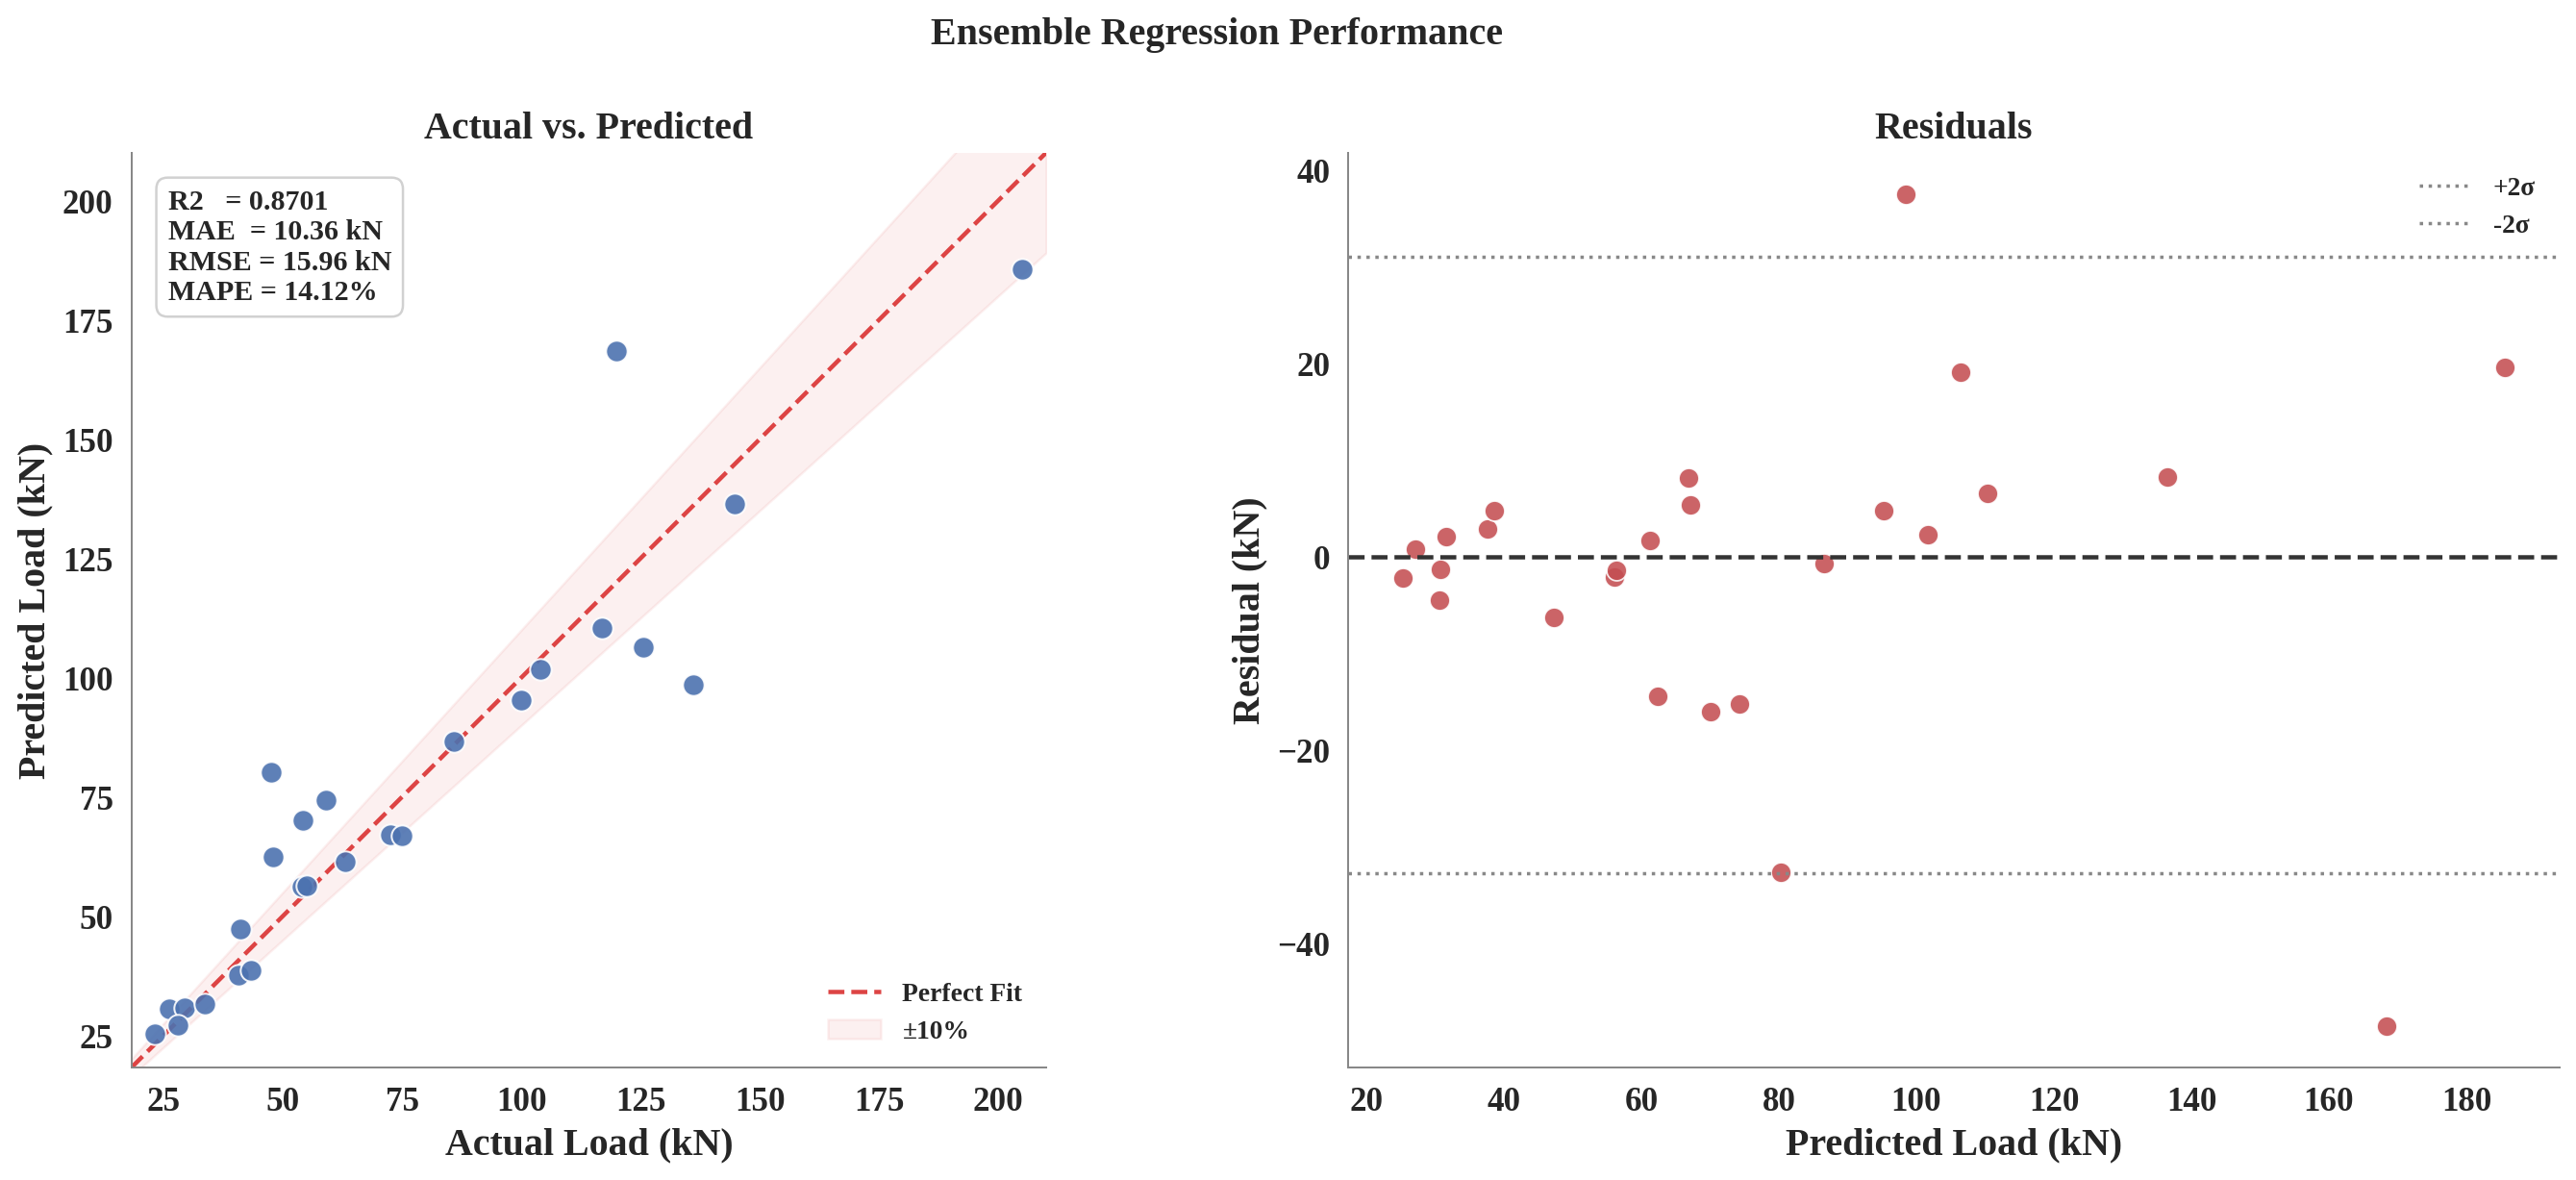

Saved -> /content/outputs/01_actual_vs_predicted.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]

mn = min(y_load_test.min(), ens_pred_load.min()) - 5
mx = max(y_load_test.max(), ens_pred_load.max()) + 5

ax.scatter(
    y_load_test,
    ens_pred_load,
    c="#4C72B0",
    s=80,
    edgecolors="white",
    lw=0.8,
    zorder=3,
    alpha=0.90
)

# Perfect prediction line
ax.plot(
    [mn, mx],
    [mn, mx],
    color="#DD4444",
    lw=1.8,
    ls="--",
    label="Perfect Fit"
)

# Correct ±10% band around y = x
x_band = np.linspace(mn, mx, 200)
ax.fill_between(
    x_band,
    0.9 * x_band,
    1.1 * x_band,
    color="#DD4444",
    alpha=0.08,
    label="±10%"
)

box_txt = (
    f"R2   = {ens_r2:.4f}\n"
    f"MAE  = {ens_mae:.2f} kN\n"
    f"RMSE = {ens_rmse:.2f} kN\n"
    f"MAPE = {ens_mape:.2f}%"
)

ax.text(
    0.04,
    0.96,
    box_txt,
    transform=ax.transAxes,
    fontsize=12,
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", alpha=0.9)
)

ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Actual Load (kN)")
ax.set_ylabel("Predicted Load (kN)")
ax.set_title("Actual vs. Predicted")
ax.legend(loc="lower right", fontsize=11)
despine(ax)


# ------------------------------------------------------------
# Residual plot
# ------------------------------------------------------------
ax = axes[1]

residuals = y_load_test - ens_pred_load

print(f"Residual mean : {residuals.mean():.3f} kN")
print(f"Residual std  : {residuals.std():.3f} kN")

ax.scatter(
    ens_pred_load,
    residuals,
    c="#C44E52",
    s=70,
    edgecolors="white",
    lw=0.7,
    alpha=0.88
)

# Zero residual line
ax.axhline(
    0,
    color="#333333",
    lw=1.8,
    ls="--"
)

# ±2 sigma limits
for k in [2, -2]:
    ax.axhline(
        residuals.mean() + k * residuals.std(),
        color="#888888",
        ls=":",
        lw=1.4,
        label=f"{'+' if k > 0 else '-'}2σ"
    )

ax.set_xlabel("Predicted Load (kN)")
ax.set_ylabel("Residual (kN)")
ax.set_title("Residuals")
ax.legend(fontsize=11)
despine(ax)

plt.suptitle("Ensemble Regression Performance", fontsize=16, fontweight="bold")
plt.subplots_adjust(wspace=0.28)
plt.tight_layout()

out = f"{OUTPUT_DIR}/01_actual_vs_predicted.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")

---
## Section 11b - Classification Performance Visualization

Generating classification performance visualizations

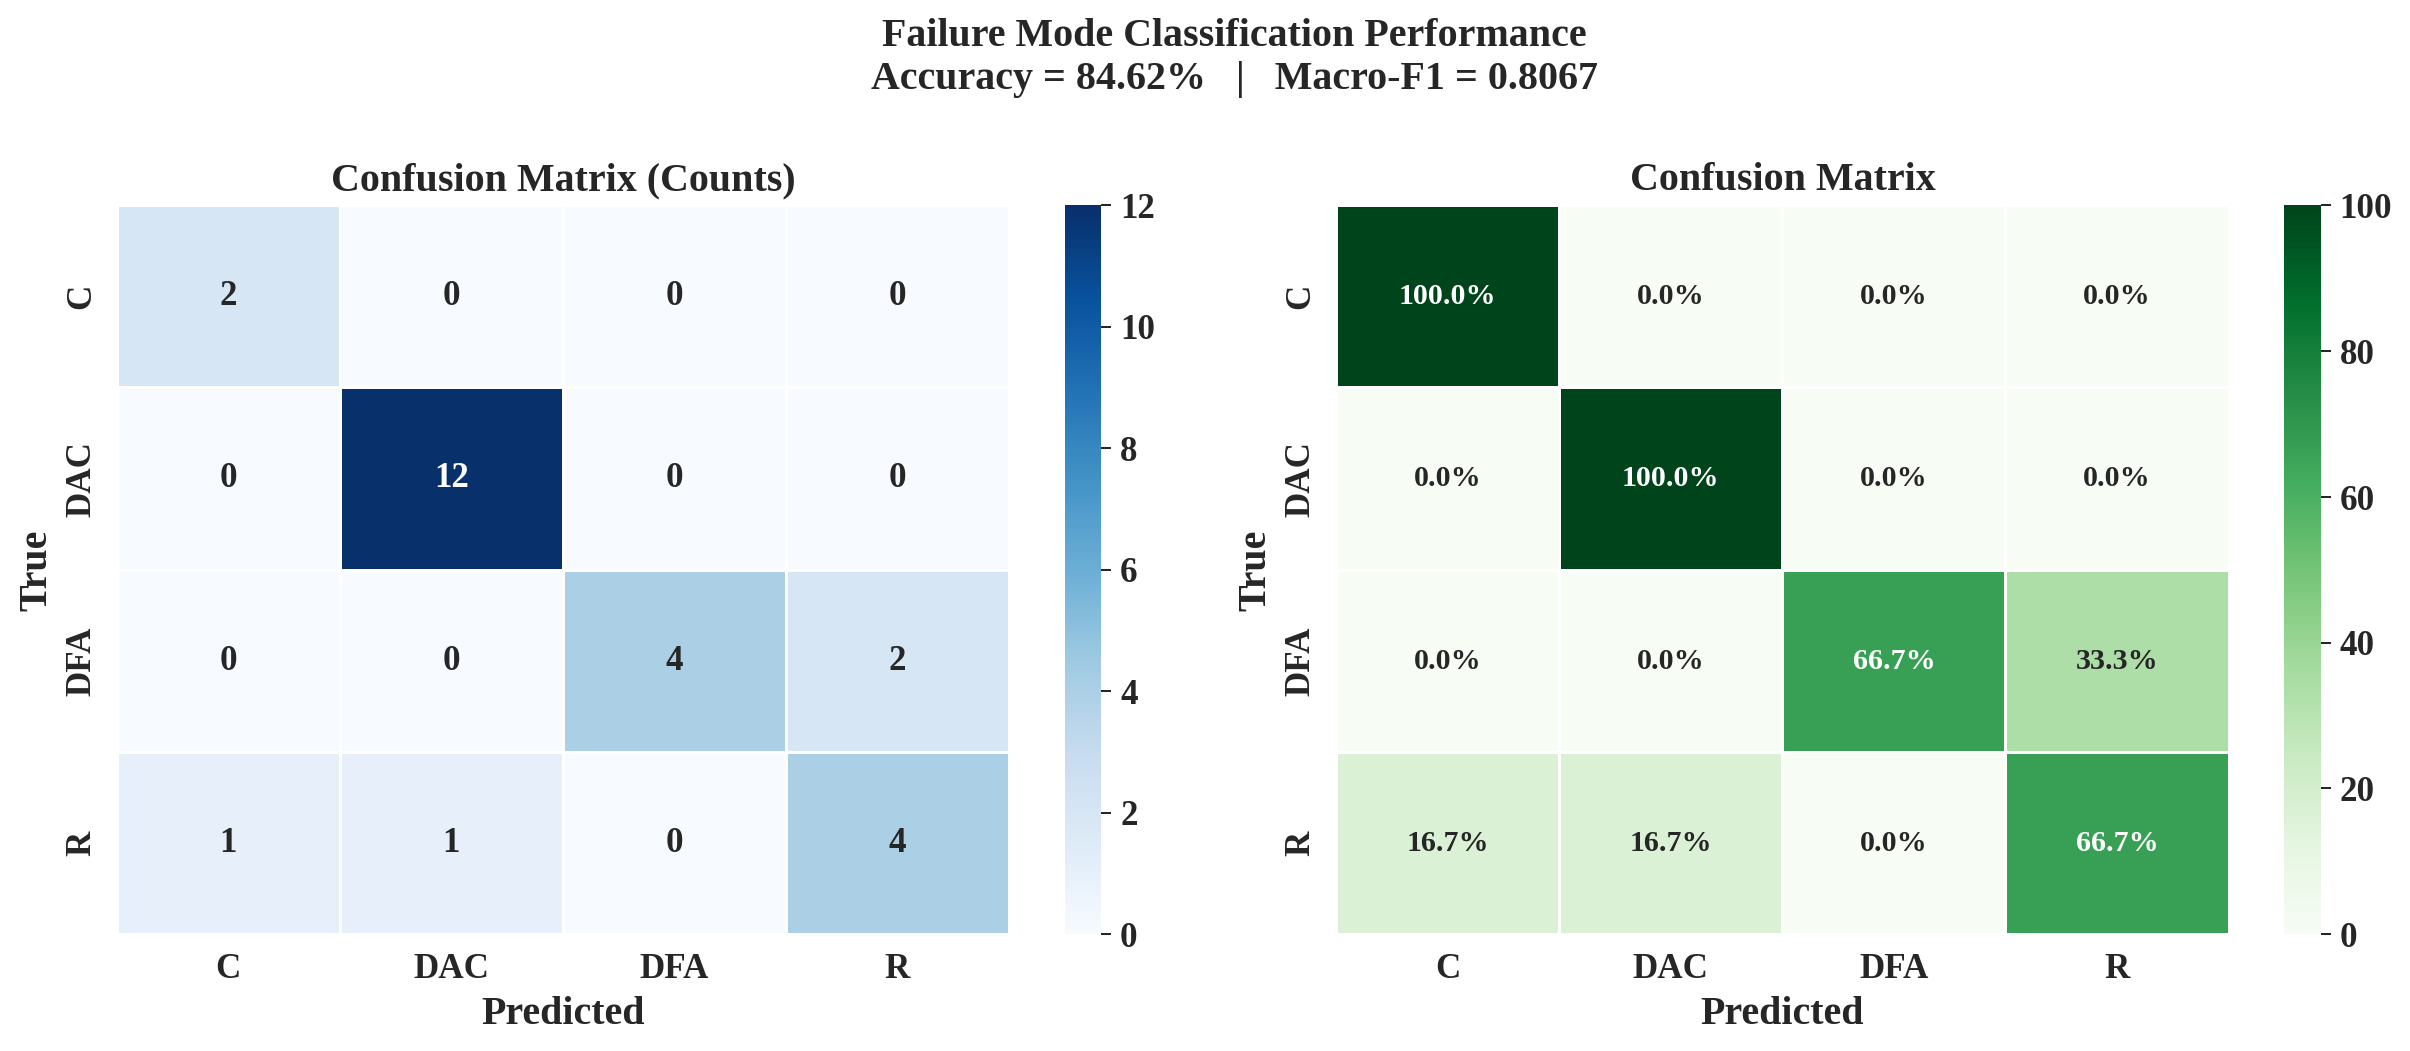

Saved -> /content/outputs/02_confusion_matrix.png


In [ ]:
cm     = confusion_matrix(y_fail_test, ens_pred_fail)
cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------------------------
# Confusion matrix (counts)
# ------------------------------------------------------------
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[0],
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 14, "weight": "bold"}
)

axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------
sns.heatmap(
    cm_pct,
    annot=np.array([[f"{v:.1f}%" for v in row] for row in cm_pct]),
    fmt="",
    cmap="Greens",
    vmin=0,
    vmax=100,
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[1],
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 12, "weight": "bold"}
)

axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

# Clean style
despine(axes[0])
despine(axes[1])

plt.suptitle(
    f"Failure Mode Classification Performance\n"
    f"Accuracy = {ens_acc*100:.2f}%   |   Macro-F1 = {ens_f1:.4f}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

out = f"{OUTPUT_DIR}/02_confusion_matrix.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")

---
## Section 11c - Model Comparison Visualization

Generating model comparison visualizations

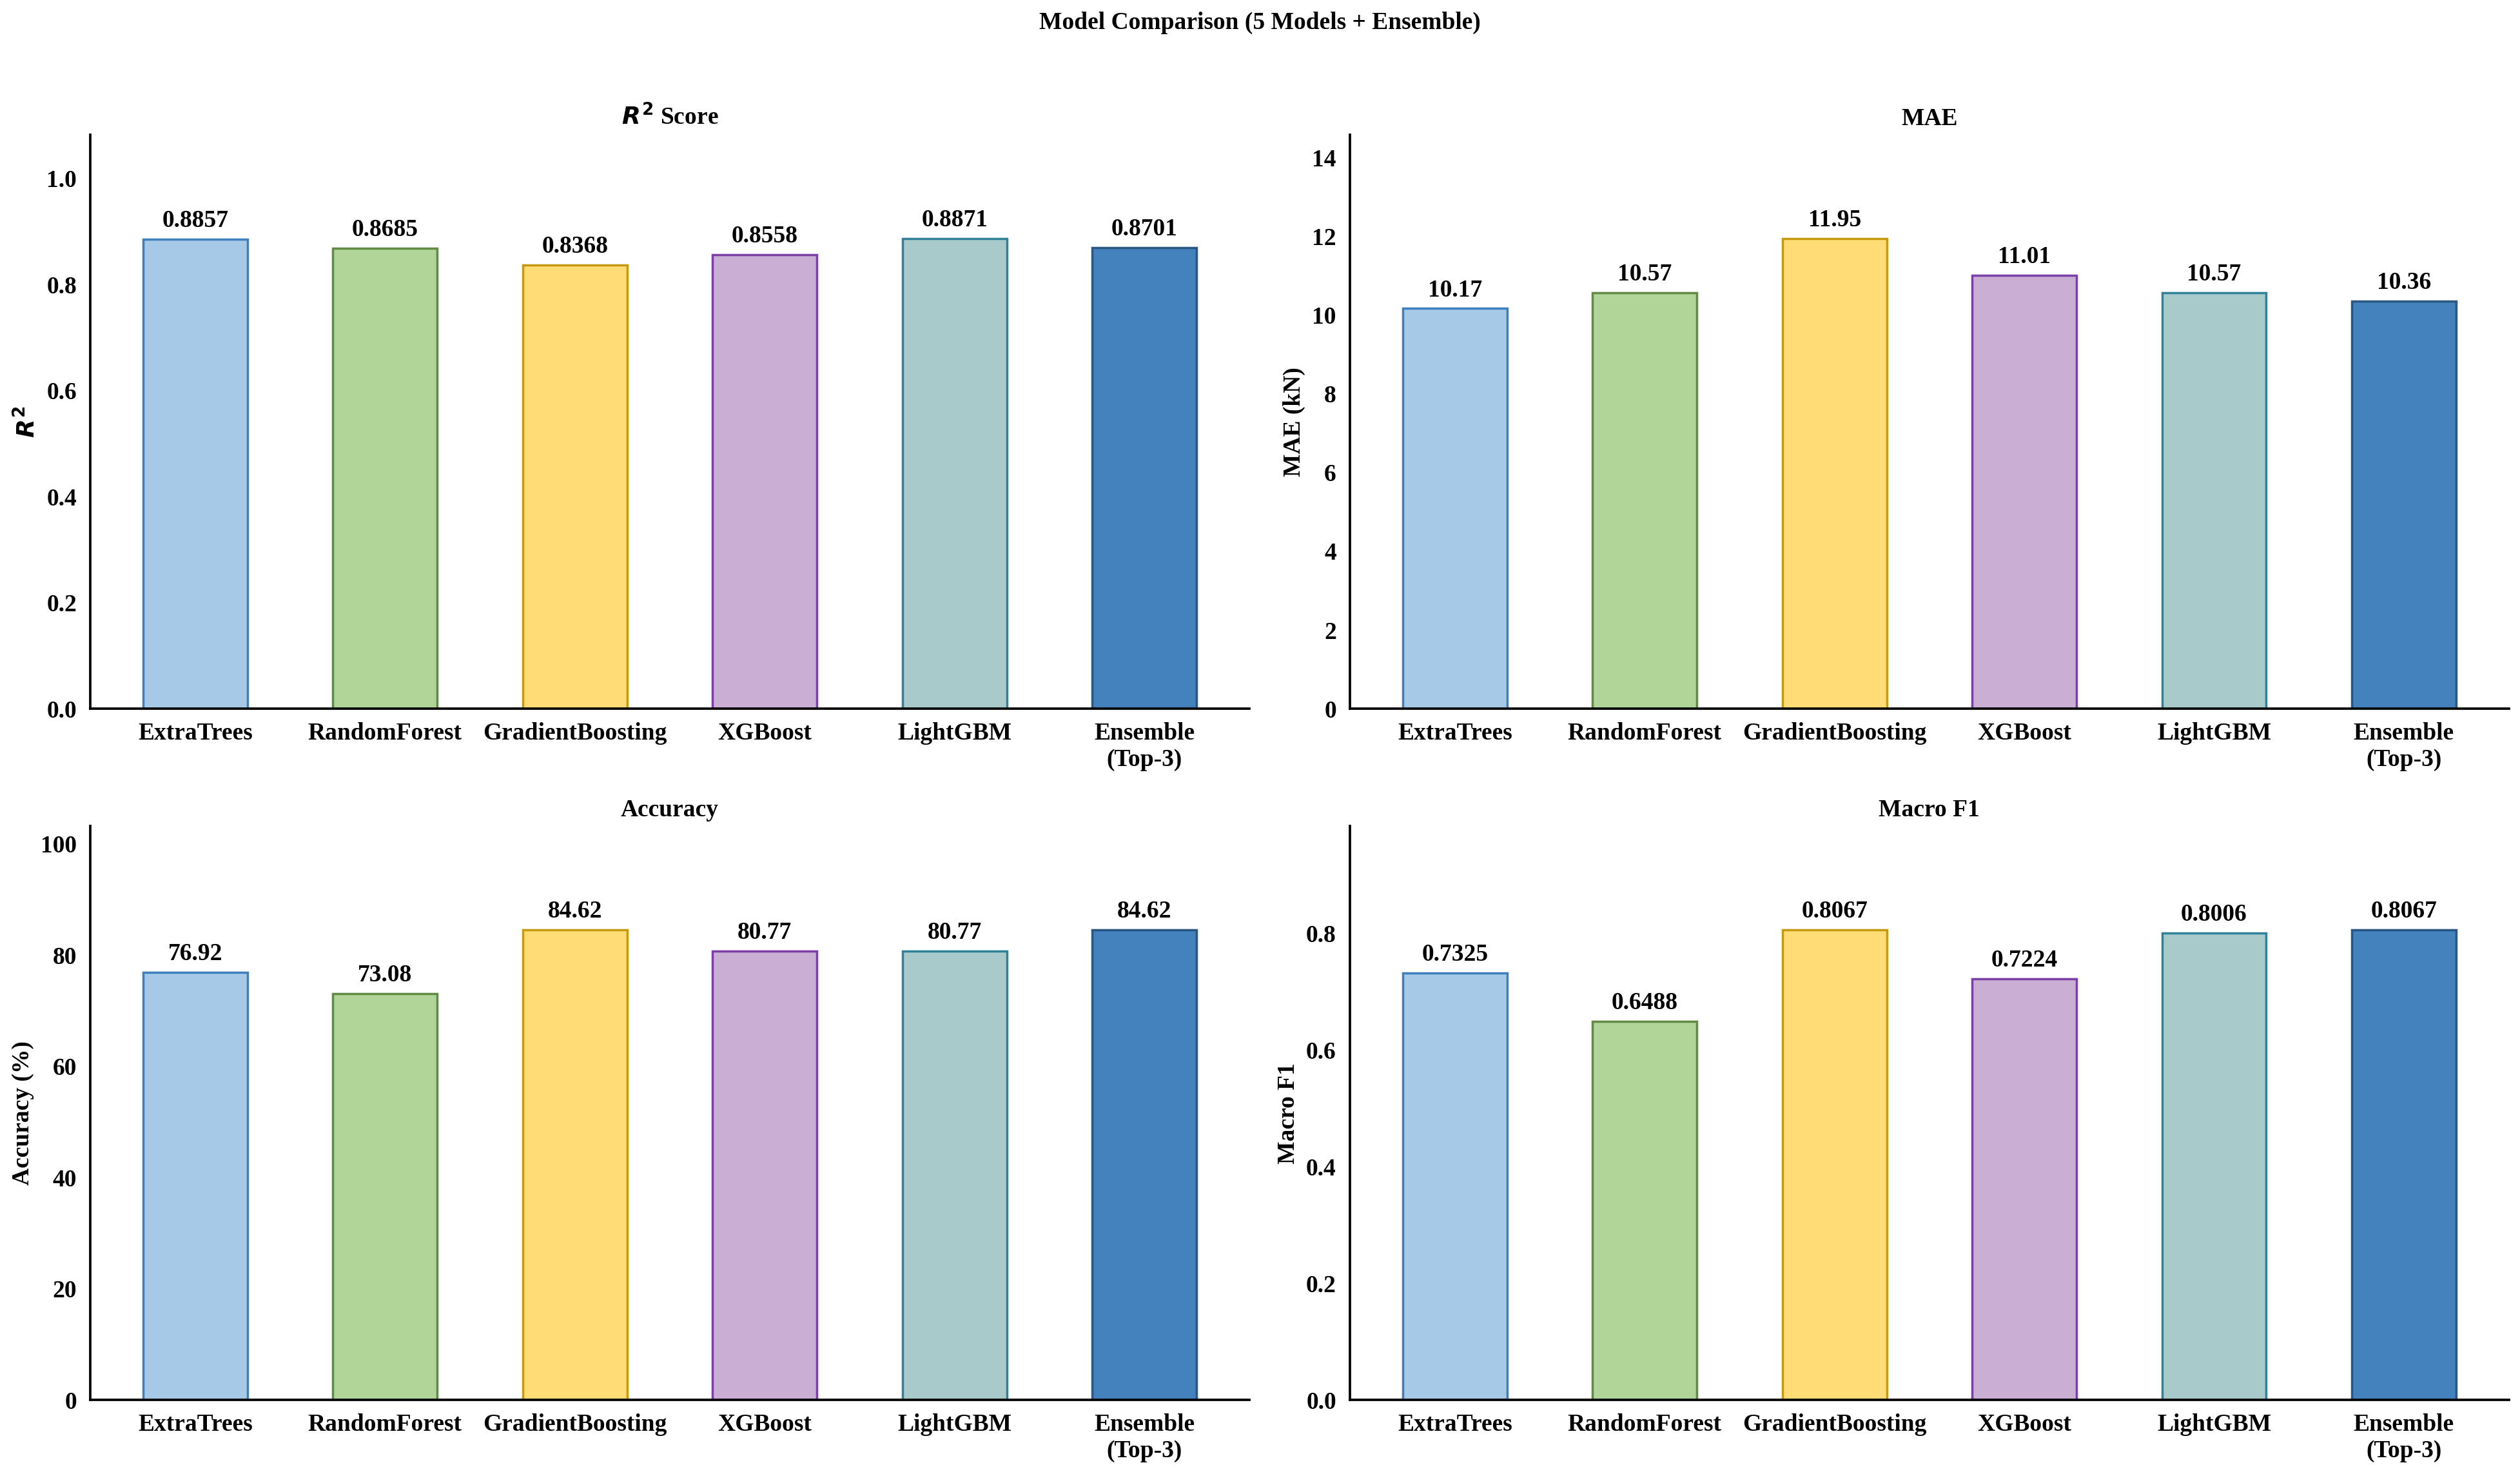

Saved -> /content/outputs/03_model_comparison.png


In [ ]:
MODEL_NAMES = list(reg_results.keys()) + ["Ensemble\n(Top-3)"]

r2_vals  = [reg_results[n]["R2"]       for n in list(reg_results)] + [ens_r2]
mae_vals = [reg_results[n]["MAE"]      for n in list(reg_results)] + [ens_mae]

acc_vals = [cls_results[n]["Acc"]*100 for n in list(cls_results)] + [ens_acc*100]
f1_vals  = [cls_results[n]["F1"]       for n in list(cls_results)] + [ens_f1]

COLORS = ["#9DC3E6", "#A9D18E", "#FFD966", "#C5A5CF", "#9FC5C5", "#2E75B6"]
EDGES  = ["#2E75B6", "#538135", "#BF9000", "#7030A0", "#1F7891", "#1F4E79"]


def annotated_bar(ax, labels, vals, ylabel, title,
                  lower_better=False, fmt=".4f"):

    bars = ax.bar(
        labels,
        vals,
        color=COLORS,
        edgecolor=EDGES,
        linewidth=1.4,
        alpha=0.90,
        width=0.55
    )

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals)*0.015,
            f"{v:{fmt}}",
            ha="center",
            va="bottom",
            fontsize=15,
            fontweight="bold",
            color="black"
        )

    ax.set_ylabel(
        ylabel,
        fontsize=15,
        fontweight="bold",
        color="black"
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        color="black"
    )

    ax.tick_params(
        axis="both",
        labelsize=15,
        width=1.5,
        length=5,
        colors="black"
    )

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
        tick.set_color("black")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color("black")

    ax.set_ylim(0, max(vals)*1.22)

    despine(ax)

    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")


fig, axes = plt.subplots(2, 2, figsize=(22, 13))

annotated_bar(
    axes[0,0],
    MODEL_NAMES,
    r2_vals,
    r"$R^2$",
    r"$R^2$ Score"
)

annotated_bar(
    axes[0,1],
    MODEL_NAMES,
    mae_vals,
    "MAE (kN)",
    "MAE",
    lower_better=True,
    fmt=".2f"
)

annotated_bar(
    axes[1,0],
    MODEL_NAMES,
    acc_vals,
    "Accuracy (%)",
    "Accuracy",
    fmt=".2f"
)

annotated_bar(
    axes[1,1],
    MODEL_NAMES,
    f1_vals,
    "Macro F1",
    "Macro F1"
)

plt.suptitle(
    "Model Comparison (5 Models + Ensemble)",
    fontsize=15,
    fontweight="bold",
    color="black"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

out = f"{OUTPUT_DIR}/03_model_comparison.png"

plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")

---
## Section 12  - SHAP-Based Model Interpretability

[SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/) decomposes each
prediction into signed per-feature contributions grounded in cooperative game theory.

`shap.TreeExplainer` is used  -  exact (no sampling) for all tree-based models here.

| Plot | File | Task |
|------|------|------|
| Beeswarm Summary | `05_shap_reg_beeswarm.png` | Regression |
| Mean Absolute SHAP Importance | `06_shap_reg_bar.png` | Regression |
| Dependence (top-3 features) | `07_shap_reg_dependence.png` | Regression |
| Beeswarm Summary | `08_shap_cls_beeswarm.png` | Classification |
| Mean \|SHAP\| Bar | `09_shap_cls_bar.png` | Classification |

Best regression model for SHAP : GradientBoosting


/tmp/ipykernel_3017/2764632880.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


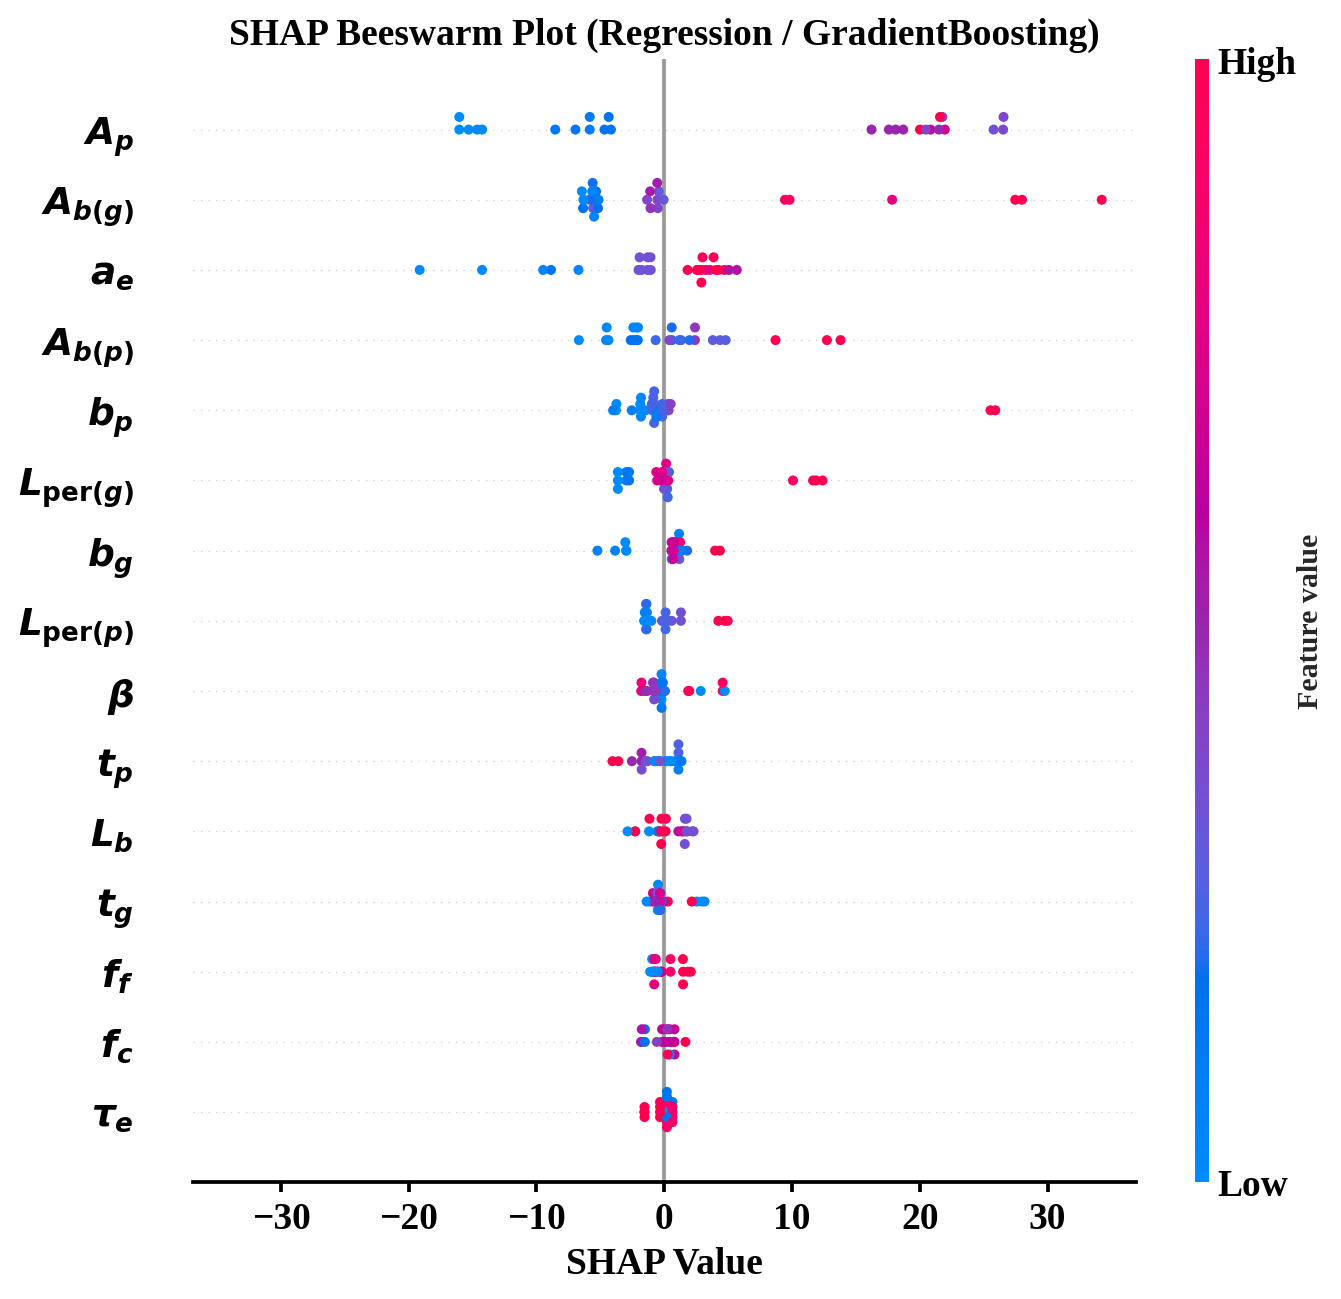

Saved -> /content/outputs/05_shap_reg_beeswarm.png


/tmp/ipykernel_3017/2764632880.py:111: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


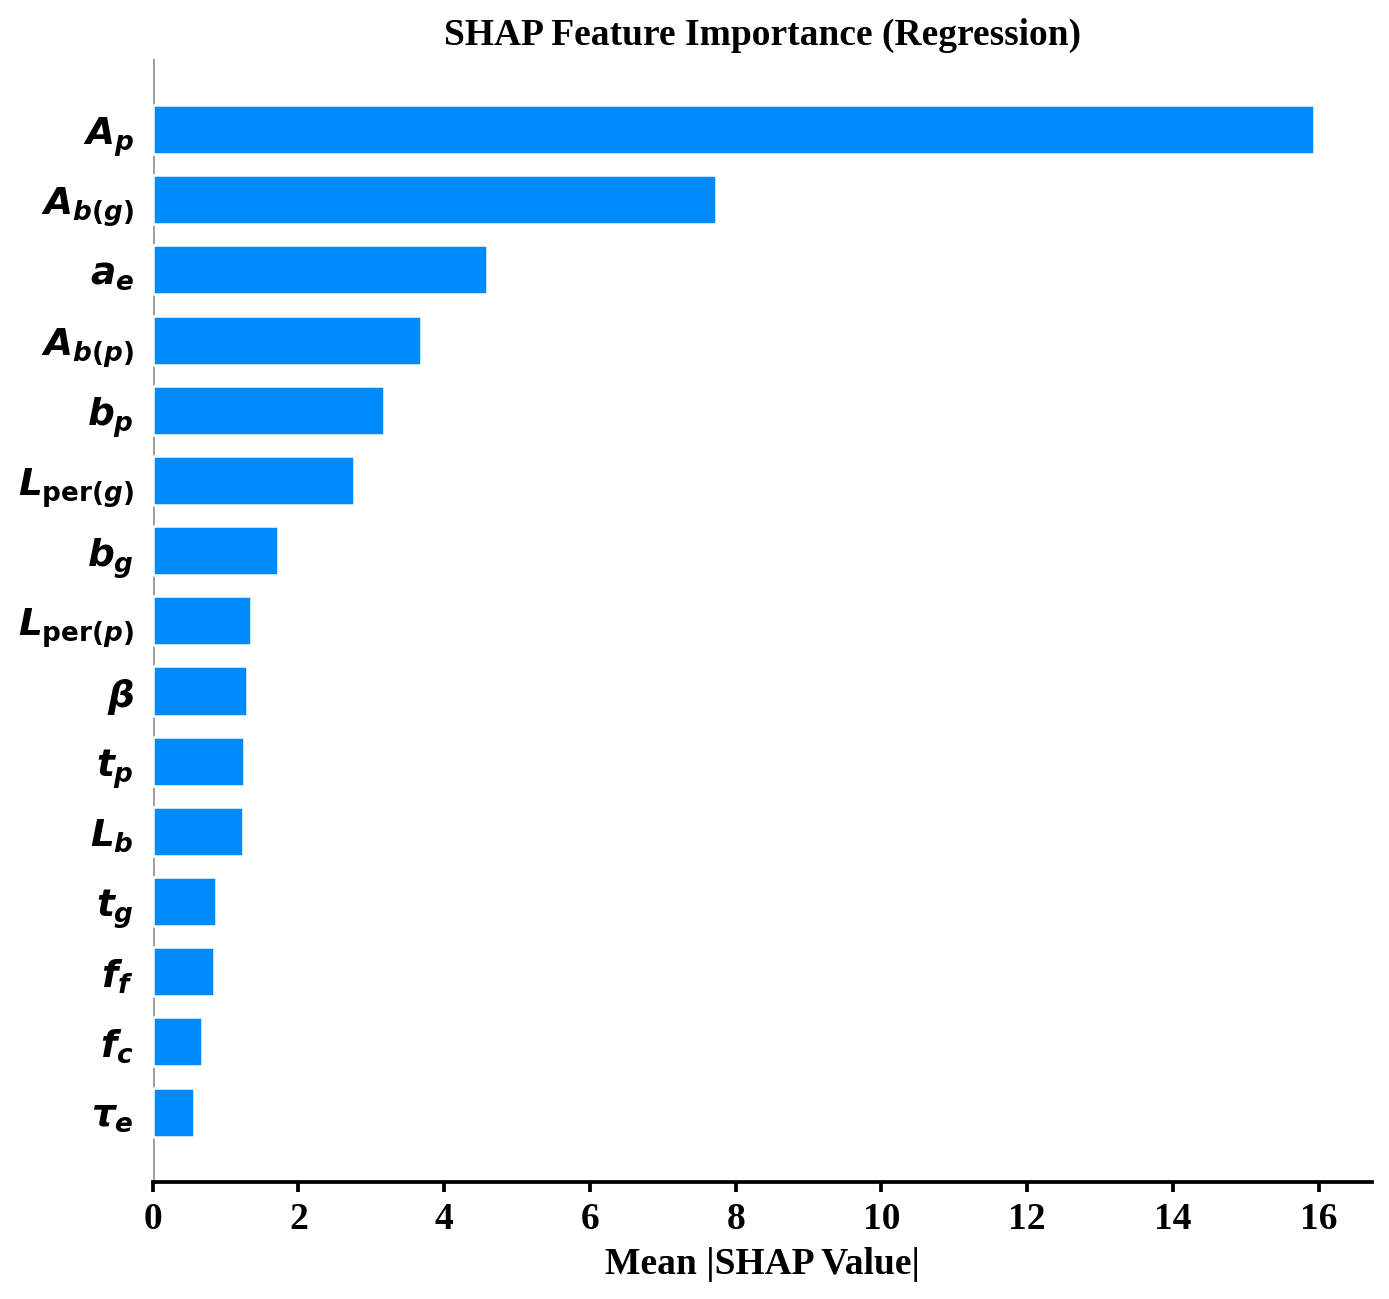

Saved -> /content/outputs/06_shap_reg_bar.png


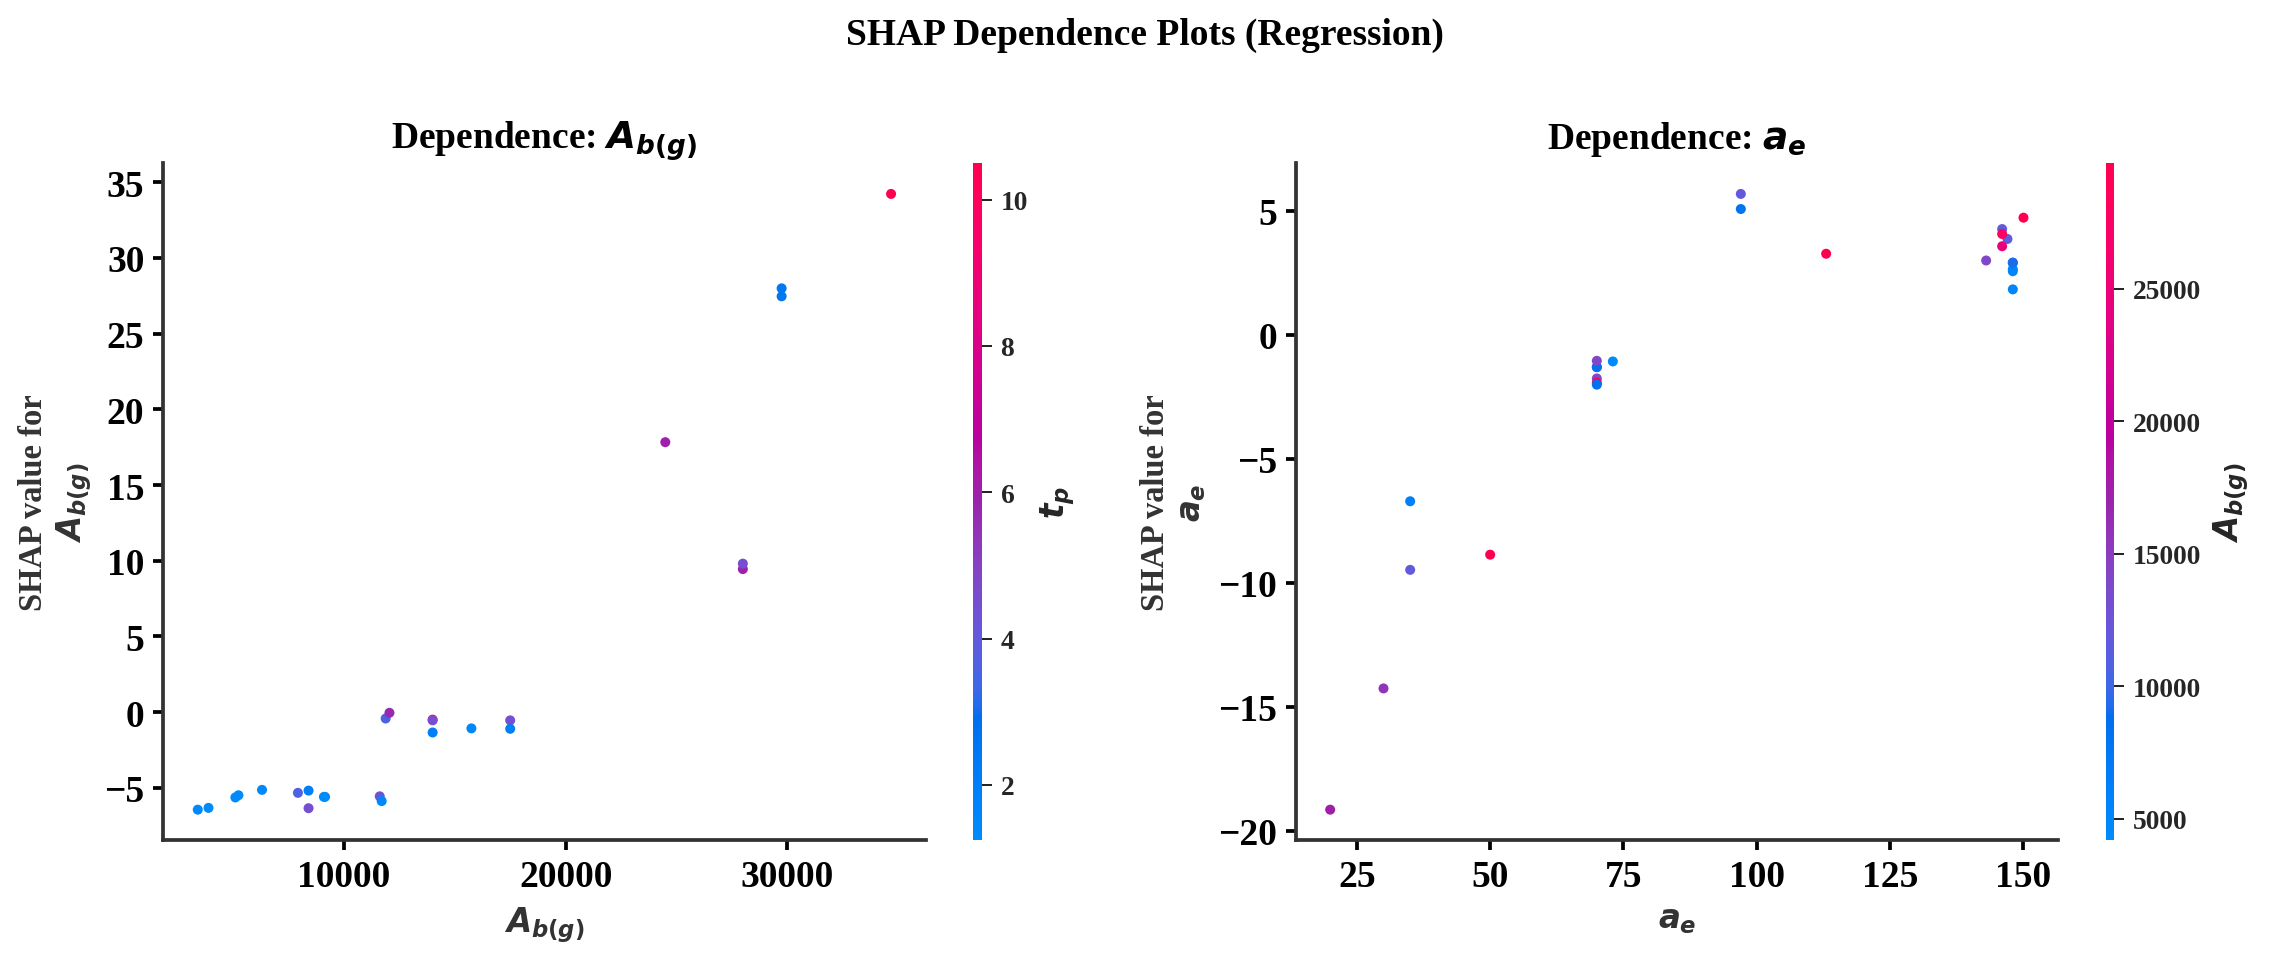

Saved -> /content/outputs/07_shap_reg_dependence.png


/tmp/ipykernel_3017/2764632880.py:271: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


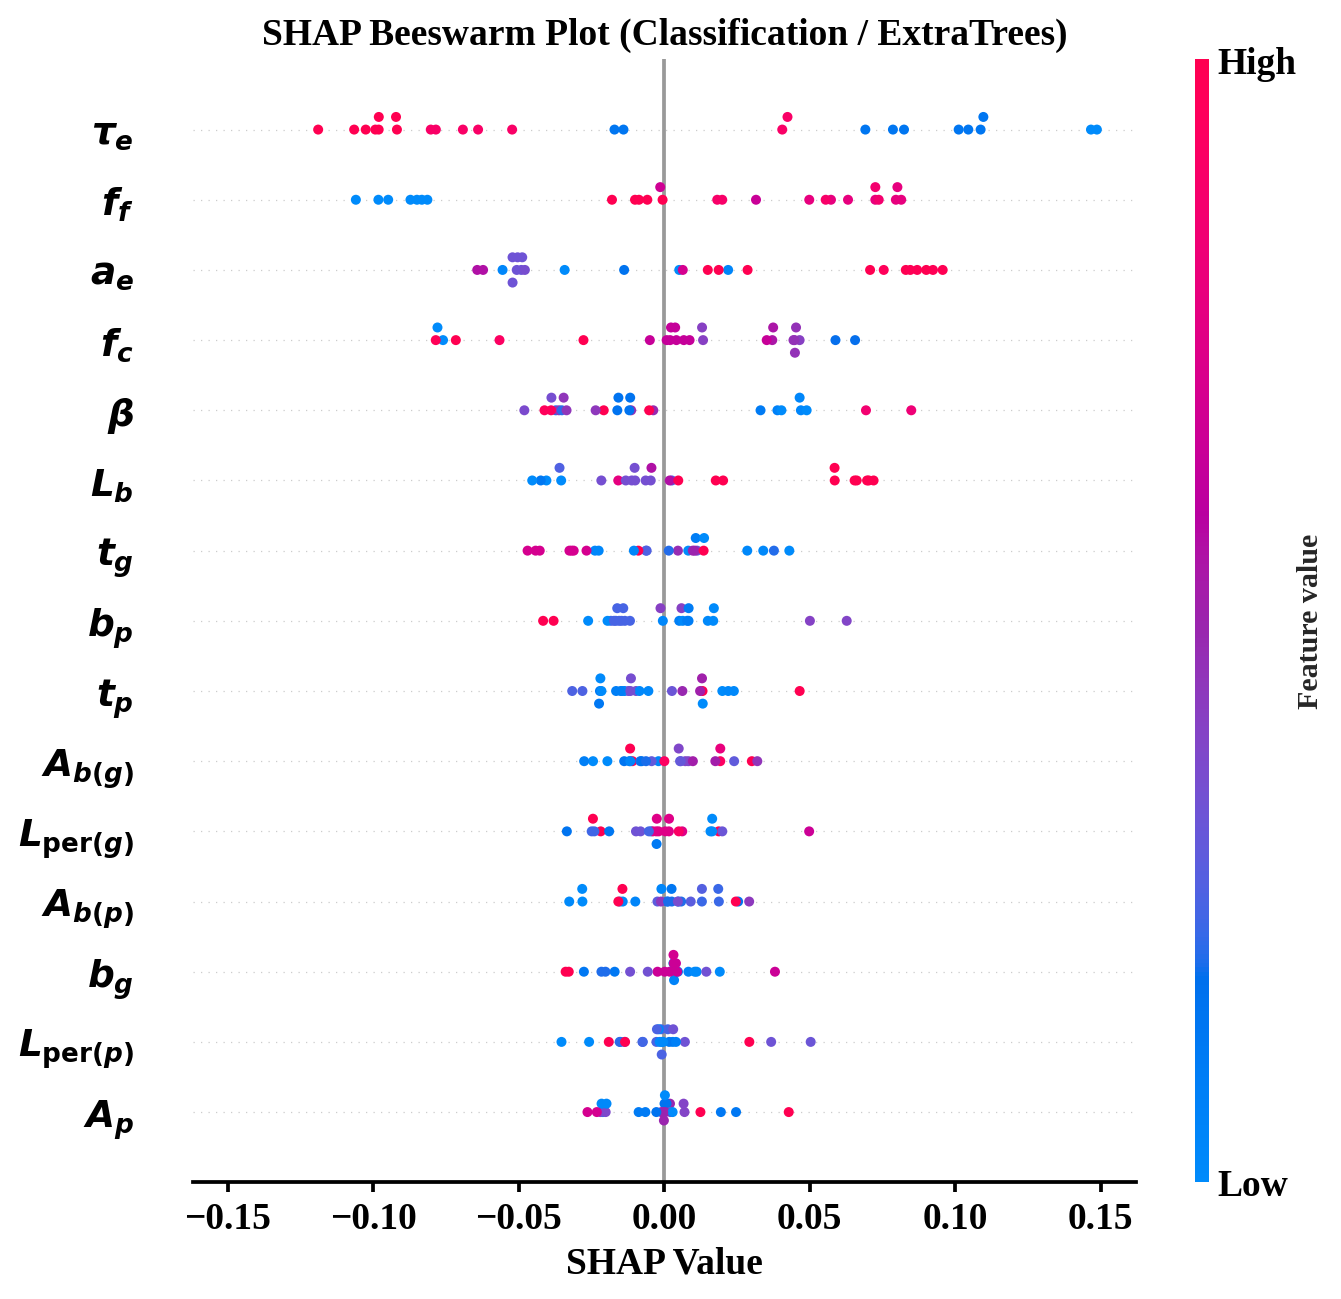

Saved -> /content/outputs/08_shap_cls_beeswarm.png


/tmp/ipykernel_3017/2764632880.py:320: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


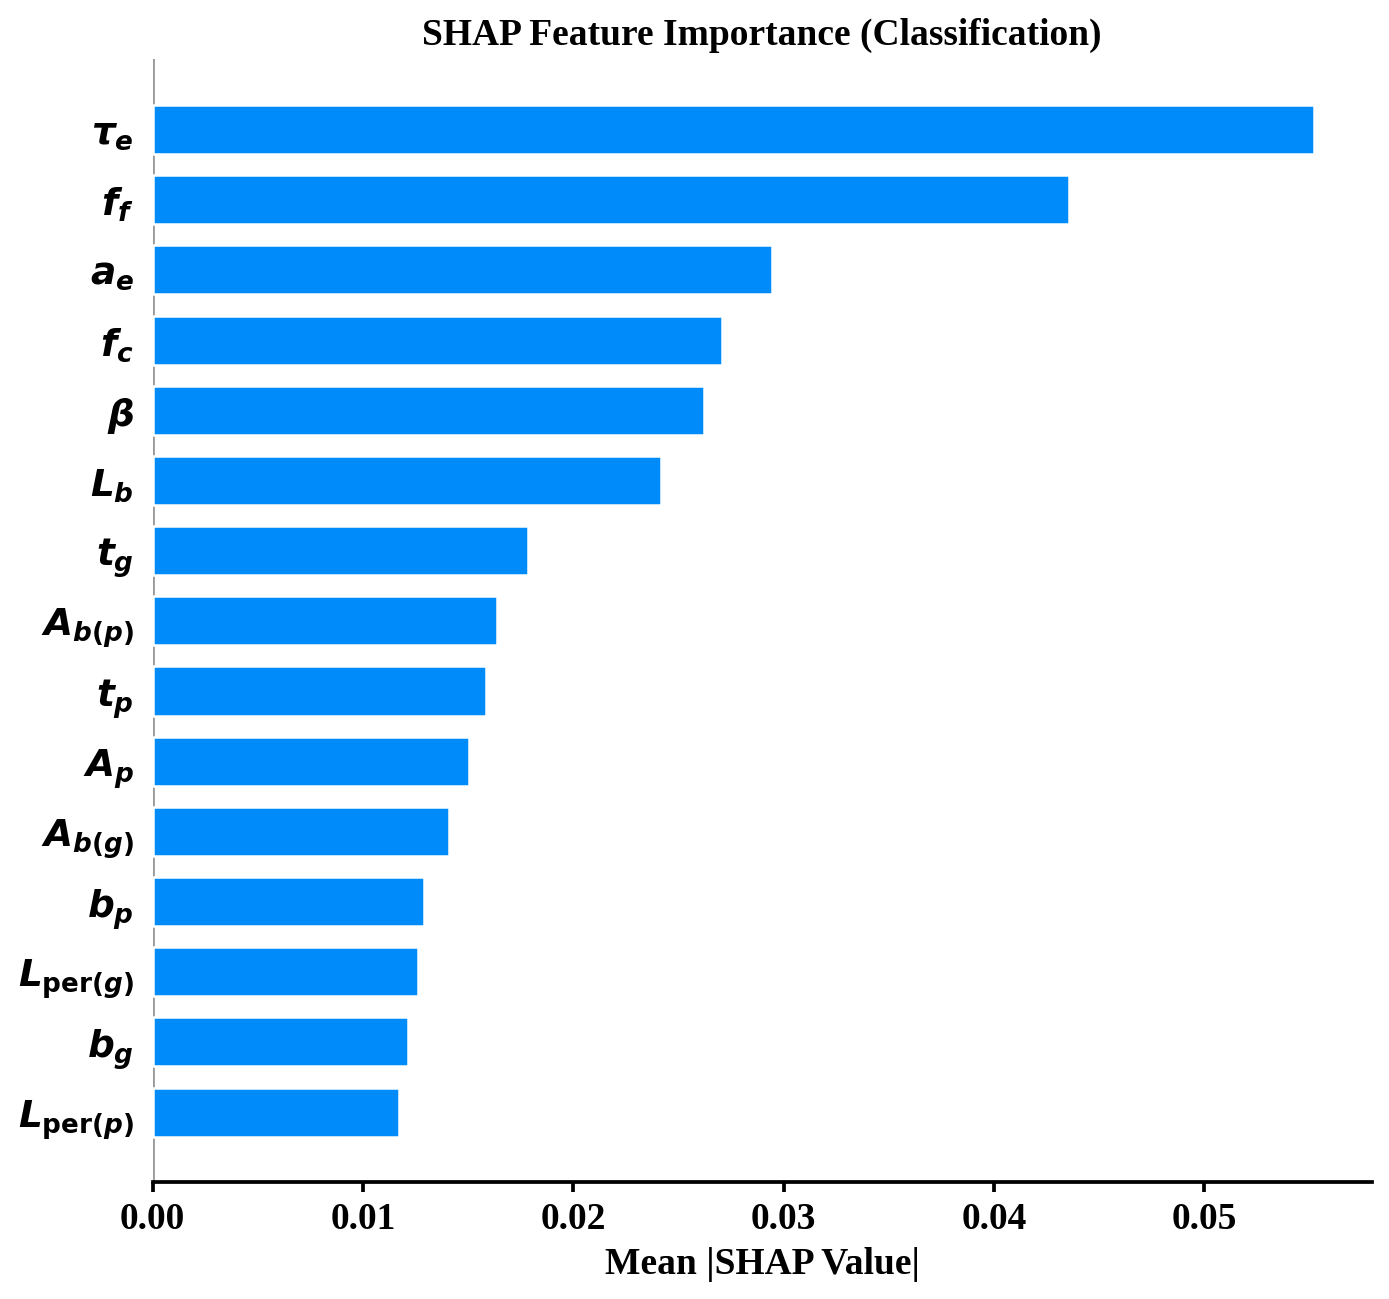

Saved -> /content/outputs/09_shap_cls_bar.png


In [ ]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

X_test_df  = pd.DataFrame(X_test, columns=ABBREV_LABELS)
X_train_df = pd.DataFrame(X_train, columns=ABBREV_LABELS)

def clean_shap_fig():
    fig = plt.gcf()
    fig.patch.set_facecolor("white")

    for ax in fig.get_axes():

        ax.set_facecolor("white")
        ax.grid(False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)

        ax.spines["left"].set_color("black")
        ax.spines["bottom"].set_color("black")

        ax.tick_params(
            axis="both",
            labelsize=15,
            width=1.5,
            colors="black"
        )


        ax.xaxis.label.set_fontsize(15)
        ax.xaxis.label.set_fontweight("bold")
        ax.xaxis.label.set_color("black")

        ax.yaxis.label.set_fontsize(15)
        ax.yaxis.label.set_fontweight("bold")
        ax.yaxis.label.set_color("black")


        for tick in ax.get_xticklabels():
            tick.set_fontweight("bold")
            tick.set_color("black")

        for tick in ax.get_yticklabels():
            tick.set_fontweight("bold")
            tick.set_color("black")

    if len(fig.axes) > 1:

        cbar_ax = fig.axes[-1]

        cbar_ax.yaxis.label.set_fontsize(15)
        cbar_ax.yaxis.label.set_fontweight("bold")
        cbar_ax.yaxis.label.set_color("black")

        cbar_ax.tick_params(
            labelsize=15,
            colors="black",
            width=1.5
        )

        for tick in cbar_ax.get_yticklabels():
            tick.set_fontweight("bold")
            tick.set_color("black")


# ------------------------------------------------------------
# Regression SHAP Analysis
# ------------------------------------------------------------

best_reg_name = top3_reg[0]

print(f"Best regression model for SHAP : {best_reg_name}")

explainer_reg = shap.TreeExplainer(
    tuned_reg[best_reg_name],
    X_train_df
)

shap_vals_reg = explainer_reg.shap_values(X_test_df)

# ============================================================
# Regression SHAP Beeswarm
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_vals_reg,
    X_test_df,
    plot_type="dot",
    show=False,
    max_display=15
)

clean_shap_fig()

ax = plt.gca()

_xm = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
ax.set_xlim(-_xm, _xm)

ax.set_xlabel(
    "SHAP Value",
    fontsize=15,
    fontweight="bold",
    color="black"
)

for tick in ax.get_yticklabels():
    tick.set_fontsize(15)
    tick.set_fontweight("bold")
    tick.set_color("black")

plt.title(
    f"SHAP Beeswarm Plot (Regression / {best_reg_name})",
    fontsize=15,
    fontweight="bold",
    color="black"
)

plt.tight_layout()

out = f"{OUTPUT_DIR}/05_shap_reg_beeswarm.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")


# ============================================================
# Regression SHAP Feature Importance
# ============================================================

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_vals_reg,
    X_test_df,
    plot_type="bar",
    show=False,
    max_display=15
)

clean_shap_fig()

ax = plt.gca()

ax.set_xlabel(
    "Mean |SHAP Value|",
    fontsize=15,
    fontweight="bold",
    color="black"
)

for tick in ax.get_yticklabels():
    tick.set_fontsize(15)
    tick.set_fontweight("bold")
    tick.set_color("black")

plt.title(
    "SHAP Feature Importance (Regression)",
    fontsize=15,
    fontweight="bold",
    color="black"
)

plt.tight_layout()

out = f"{OUTPUT_DIR}/06_shap_reg_bar.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")


# ============================================================
# SHAP Dependence Plots
# ============================================================

selected_dep_features = [r"$A_{b(g)}$", r"$a_e$"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, feat in zip(axes, selected_dep_features):

    shap.dependence_plot(
        feat,
        shap_vals_reg,
        X_test_df,
        ax=ax,
        show=False
    )

    ax.set_title(
        f"Dependence: {feat}",
        fontsize=15,
        fontweight="bold",
        color="black"
    )

    ax.set_facecolor("white")
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    ax.tick_params(
        axis="both",
        labelsize=15,
        width=1.5,
        colors="black"
    )

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

fig.patch.set_facecolor("white")

plt.suptitle(
    "SHAP Dependence Plots (Regression)",
    fontsize=15,
    fontweight="bold",
    color="black"
)

plt.tight_layout()

out = f"{OUTPUT_DIR}/07_shap_reg_dependence.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")


# ------------------------------------------------------------
# Classification SHAP Analysis
# ------------------------------------------------------------

SHAP_NO_MULTICLASS = {"GradientBoosting"}
n_classes = len(CLASSES)

best_cls_name = top3_cls[0]
shap_cls_name = best_cls_name

if n_classes > 2 and shap_cls_name in SHAP_NO_MULTICLASS:

    for cand_name, _ in cls_ranking:

        if cand_name not in SHAP_NO_MULTICLASS:
            shap_cls_name = cand_name

            print(
                f"GradientBoosting incompatible with multi-class SHAP; "
                f"using [{shap_cls_name}]."
            )
            break

explainer_cls = shap.TreeExplainer(
    tuned_cls[shap_cls_name],
    X_train_df
)

shap_vals_cls = explainer_cls.shap_values(X_test_df)

if isinstance(shap_vals_cls, list):

    shap_2d = np.mean(np.abs(np.array(shap_vals_cls)), axis=0)

    dominant_cls = int(np.argmax(np.bincount(y_fail_test)))
    shap_display = shap_vals_cls[dominant_cls]

elif hasattr(shap_vals_cls, "shape") and shap_vals_cls.ndim == 3:

    shap_2d = np.mean(np.abs(shap_vals_cls), axis=2)

    dominant_cls = int(np.argmax(np.bincount(y_fail_test)))
    shap_display = shap_vals_cls[:, :, dominant_cls]

else:

    shap_2d = shap_display = shap_vals_cls


# ============================================================
# Classification SHAP Beeswarm
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_display,
    X_test_df,
    plot_type="dot",
    show=False,
    max_display=15
)

clean_shap_fig()

ax = plt.gca()

_xm = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
ax.set_xlim(-_xm, _xm)

ax.set_xlabel(
    "SHAP Value",
    fontsize=15,
    fontweight="bold",
    color="black"
)

for tick in ax.get_yticklabels():
    tick.set_fontsize(15)
    tick.set_fontweight("bold")
    tick.set_color("black")

plt.title(
    f"SHAP Beeswarm Plot (Classification / {shap_cls_name})",
    fontsize=15,
    fontweight="bold",
    color="black"
)

plt.tight_layout()

out = f"{OUTPUT_DIR}/08_shap_cls_beeswarm.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")


# ============================================================
# Classification SHAP Feature Importance
# ============================================================

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_2d,
    X_test_df,
    plot_type="bar",
    show=False,
    max_display=15
)

clean_shap_fig()

ax = plt.gca()

ax.set_xlabel(
    "Mean |SHAP Value|",
    fontsize=15,
    fontweight="bold",
    color="black"
)

for tick in ax.get_yticklabels():
    tick.set_fontsize(15)
    tick.set_fontweight("bold")
    tick.set_color("black")

plt.title(
    "SHAP Feature Importance (Classification)",
    fontsize=15,
    fontweight="bold",
    color="black"
)

plt.tight_layout()

out = f"{OUTPUT_DIR}/09_shap_cls_bar.png"
plt.savefig(out, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved -> {out}")

---
## Section 13 - Results Export & Final Summary

Full-dataset predictions, test-only predictions, and a model comparison table are written to a multi-sheet Excel workbook.

In [ ]:
# Full-dataset predictions
ens_pred_load_all = ens_reg.predict(X)
ens_pred_fail_all = ens_cls.predict(X)
ens_pred_fail_lbl = le.inverse_transform(ens_pred_fail_all)

# Rebuild train/test labels consistently
_, _, _, _, idx_tr, idx_te = train_test_split(
    X, y_load, np.arange(len(df)),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_fail,
)
split_labels = np.array(["Train"] * len(df))
split_labels[idx_te] = "Test"

results_df = df.copy()
results_df["Predicted_Load"]    = ens_pred_load_all.round(2)
results_df["Load_Error_kN"]     = (ens_pred_load_all - y_load).round(2)
results_df["Load_Abs_Error_kN"] = np.abs(ens_pred_load_all - y_load).round(2)
results_df["Load_MAPE_pct"]     = (np.abs((ens_pred_load_all-y_load)/y_load)*100).round(2)
results_df["Predicted_Failure"] = ens_pred_fail_lbl
results_df["Failure_Correct"]   = (ens_pred_fail_lbl == df[TARGET_CLS].values)
results_df["Split"]             = split_labels

# Model comparison table
rows = []
for n in list(reg_results.keys()):
    rows.append({
        "Model": n, "Type": "Individual",
        "Load_R2"       : round(reg_results[n]["R2"],   4),
        "Load_MAE_kN"   : round(reg_results[n]["MAE"],  2),
        "Load_RMSE_kN"  : round(reg_results[n]["RMSE"], 2),
        "Fail_Acc_pct"  : round(cls_results[n]["Acc"]*100, 2),
        "Fail_MacroF1"  : round(cls_results[n]["F1"],   4),
        "Reg_In_Ensemble": n in top3_reg,
        "Cls_In_Ensemble": n in top3_cls,
    })
rows.append({
    "Model"          : f"Ensemble ({', '.join(top3_reg)})",
    "Type"           : "Ensemble",
    "Load_R2"        : round(ens_r2,   4),
    "Load_MAE_kN"    : round(ens_mae,  2),
    "Load_RMSE_kN"   : round(ens_rmse, 2),
    "Fail_Acc_pct"   : round(ens_acc*100, 2),
    "Fail_MacroF1"   : round(ens_f1,   4),
    "Reg_In_Ensemble": True,
    "Cls_In_Ensemble": True,
})
comparison_df = pd.DataFrame(rows)

OUT_XLSX = f"{OUTPUT_DIR}/NSM_FRP_Ensemble_Results.xlsx"
with pd.ExcelWriter(OUT_XLSX, engine="xlsxwriter") as writer:
    results_df.to_excel(writer, sheet_name="All_Predictions",  index=False)
    results_df[results_df["Split"]=="Test"].to_excel(
        writer, sheet_name="Test_Predictions", index=False)
    comparison_df.to_excel(writer, sheet_name="Model_Comparison", index=False)
    for ws_name in writer.sheets:
        writer.sheets[ws_name].set_column(0, 30, 22)

print(f"Saved -> {OUT_XLSX}")

# -- Final Summary ------------------------------------------
print("\n" + "="*65)
print(" FINAL MODEL SUMMARY")
print("="*65)
print(f"  Dataset        : {len(df)} specimens  |  {X.shape[1]} features")
print(f" Train / Test split : {X_train.shape[0]} / {X_test.shape[0]} samples")
print(f"  Top-3 Reg      : {top3_reg}")
print(f"  Top-3 Cls      : {top3_cls}")
print()
print("  ULTIMATE LOAD (Ensemble, Test Set):")
print(f"    R2   = {ens_r2:.4f}   MAE = {ens_mae:.2f} kN   "
      f"RMSE = {ens_rmse:.2f} kN   MAPE = {ens_mape:.2f}%")
print()
print("  FAILURE MODE (Ensemble, Test Set):")
print(f"    Acc  = {ens_acc*100:.2f}%   Macro-F1 = {ens_f1:.4f}")
print()
print("  Files saved to outputs/:")
for f in ["00a_distributions.png", "00b_correlation.png", "00c_pca.png",
          "01_actual_vs_predicted.png", "02_confusion_matrix.png",
          "03_model_comparison.png",
          "05_shap_reg_beeswarm.png", "06_shap_reg_bar.png",
          "07_shap_reg_dependence.png", "08_shap_cls_beeswarm.png",
          "09_shap_cls_bar.png", "NSM_FRP_Ensemble_Results.xlsx"]:
    print(f"    {f}")
print("="*65)
print(f"\nExcel workbook saved as : {OUT_XLSX}")

Saved -> /content/outputs/NSM_FRP_Ensemble_Results.xlsx

 FINAL MODEL SUMMARY
  Dataset        : 130 specimens  |  15 features
 Train / Test split : 104 / 26 samples
  Top-3 Reg      : ['GradientBoosting', 'XGBoost', 'ExtraTrees']
  Top-3 Cls      : ['ExtraTrees', 'GradientBoosting', 'RandomForest']

  ULTIMATE LOAD (Ensemble, Test Set):
    R2   = 0.8701   MAE = 10.36 kN   RMSE = 15.96 kN   MAPE = 14.12%

  FAILURE MODE (Ensemble, Test Set):
    Acc  = 84.62%   Macro-F1 = 0.8067

  Files saved to outputs/:
    00a_distributions.png
    00b_correlation.png
    00c_pca.png
    01_actual_vs_predicted.png
    02_confusion_matrix.png
    03_model_comparison.png
    05_shap_reg_beeswarm.png
    06_shap_reg_bar.png
    07_shap_reg_dependence.png
    08_shap_cls_beeswarm.png
    09_shap_cls_bar.png
    NSM_FRP_Ensemble_Results.xlsx

Excel workbook saved as : /content/outputs/NSM_FRP_Ensemble_Results.xlsx
